## Tokenization as Inductive Bias


---
By Mohab Yousef, Tad Silgar and Connor Wyatt


In [1]:
# Install all required libraries in Colab first
!pip -q install datasets nltk sentencepiece tokenizers transformers accelerate
!pip install -q --upgrade transformers

# Core
import os, re, math, random, time, urllib.request
from pathlib import Path
from collections import Counter
from nltk.tokenize import sent_tokenize

# Data
from datasets import load_dataset
import nltk
import pandas as pd
import matplotlib.pyplot as plt
nltk.download("punkt", quiet=True)
nltk.download('punkt')
nltk.download('punkt_tab')

# Tokenizers
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, normalizers, decoders
import sentencepiece as spm
from transformers import PreTrainedTokenizerFast

# Transformers
from transformers import (
    BertConfig,
    BertForMaskedLM,
    TrainingArguments,
    Trainer
)

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset

# Reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Using device: cuda


In [2]:
# Data sources
shakespeare_url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
morphynet_url = "https://raw.githubusercontent.com/kbatsuren/MorphyNet/refs/heads/main/eng/eng.derivational.v1.tsv"

# Helper function for light normalization
def normalize_text(text):
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    return text.strip()

# Load Tiny Shakespeare (training data)
shakespeare_text = urllib.request.urlopen(shakespeare_url).read().decode("utf-8")
shakespeare_text = normalize_text(shakespeare_text)

# Load MorphyNet (raw TSV for morphology evaluation)
morphynet_text = urllib.request.urlopen(morphynet_url).read().decode("utf-8")
morphynet_text = normalize_text(morphynet_text)

# Load WikiText-2 dataset
wikitext = load_dataset("wikitext", "wikitext-2-v1")

# Extract non-empty lines
wikitext_train_lines = [x["text"] for x in wikitext["train"] if x["text"].strip()]
wikitext_valid_lines = [x["text"] for x in wikitext["validation"] if x["text"].strip()]
wikitext_test_lines  = [x["text"] for x in wikitext["test"] if x["text"].strip()]

# Join into full text strings
wikitext_train_text = normalize_text("\n".join(wikitext_train_lines))
wikitext_valid_text = normalize_text("\n".join(wikitext_valid_lines))
wikitext_test_text  = normalize_text("\n".join(wikitext_test_lines))

# Sanity checks
print("Tiny Shakespeare characters:", len(shakespeare_text))
print("MorphyNet characters:", len(morphynet_text))
print("WikiText-2 train characters:", len(wikitext_train_text))
print("WikiText-2 validation characters:", len(wikitext_valid_text))
print("WikiText-2 test characters:", len(wikitext_test_text))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tiny Shakespeare characters: 1115393
MorphyNet characters: 8168504
WikiText-2 train characters: 10778298
WikiText-2 validation characters: 1120051
WikiText-2 test characters: 1254971


In [3]:
#Config setup
# Special tokens
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
MASK_TOKEN = "<mask>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"

SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, MASK_TOKEN, BOS_TOKEN, EOS_TOKEN]

# Shared tokenizer settings
VOCAB_SIZE = 8000
WORD_VOCAB_SIZE = VOCAB_SIZE
BPE_VOCAB_SIZE = VOCAB_SIZE
SP_VOCAB_SIZE = VOCAB_SIZE

# Sequence settings
MAX_LENGTH = 256
STRIDE = 128

# Training settings
BATCH_SIZE = 16
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 20  # Train for 20 full epochs (was 5000 steps = <3% of one epoch)
WARMUP_STEPS = 500
LOGGING_STEPS = 100
SAVE_STEPS = 1000
EVAL_STEPS = 500
MLM_PROBABILITY = 0.15

# Transformer architecture
N_LAYER = 4
N_HEAD = 8
N_EMBD = 256
INTERMEDIATE_SIZE = 1024
DROPOUT = 0.1

# Rare-word settings
RARE_WORD_MIN_FREQ = 1
RARE_WORD_MAX_FREQ = 9

# Project paths
PROJECT_DIR = Path("genetic_ai_tokenization_project")
TOKENIZER_DIR = PROJECT_DIR / "tokenizers"
MODEL_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"

TOKENIZER_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# Split Tiny Shakespeare into train and validation text
split_ratio = 0.9
split_index = int(len(shakespeare_text) * split_ratio)

shakespeare_train_text = shakespeare_text[:split_index]
shakespeare_valid_text = shakespeare_text[split_index:]


In [5]:
# Word-level tokenizer
# Regex pattern for word-level tokenization
WORD_PATTERN = r"[A-Za-z]+(?:'[A-Za-z]+)?|\d+|[^\w\s]"

def word_tokenize_text(text):
    return re.findall(WORD_PATTERN, text)

# Tokenize WikiText train split
train_word_tokens_split = word_tokenize_text(wikitext_train_text)

print("Total train word tokens:", len(train_word_tokens_split))
print("Sample train tokens:", train_word_tokens_split[:20])

# Count token frequencies
word_token_counts_split = Counter(train_word_tokens_split)

# Build vocabulary
base_vocab_size = WORD_VOCAB_SIZE - len(SPECIAL_TOKENS)
most_common_words_split = [
    token for token, _ in word_token_counts_split.most_common(base_vocab_size)
]

word_vocab_split = SPECIAL_TOKENS + most_common_words_split

# Create mappings
word2id_split = {token: idx for idx, token in enumerate(word_vocab_split)}
id2word_split = {idx: token for token, idx in word2id_split.items()}

print("Split word vocab size:", len(word_vocab_split))
print("First 20 split vocab tokens:", word_vocab_split[:20])

def encode_word_split(text):
    tokens = word_tokenize_text(text)
    return [
        word2id_split[token] if token in word2id_split else word2id_split[UNK_TOKEN]
        for token in tokens
    ]

def decode_word_split(ids):
    return " ".join([id2word_split[i] for i in ids])

sample_ids_split = encode_word_split(wikitext_train_text[:200])
print("Encoded split sample:", sample_ids_split[:20])
print("Decoded split sample:", decode_word_split(sample_ids_split[:20]))

Total train word tokens: 2237152
Sample train tokens: ['=', 'Valkyria', 'Chronicles', 'III', '=', 'Senj', 'no', 'Valkyria', '3', ':', '<', 'unk', '>', 'Chronicles', '(', 'Japanese', ':', '3', ',', 'lit']
Split word vocab size: 8000
First 20 split vocab tokens: ['<pad>', '<unk>', '<mask>', '<bos>', '<eos>', 'the', ',', '.', 'of', '<', '>', 'unk', 'and', '@', 'in', 'to', 'a', '=', '"', 'was']
Encoded split sample: [17, 3888, 4402, 866, 17, 1, 133, 3888, 82, 51, 9, 11, 10, 4402, 31, 768, 51, 82, 6, 6466]
Decoded split sample: = Valkyria Chronicles III = <unk> no Valkyria 3 : < unk > Chronicles ( Japanese : 3 , lit


In [6]:
# Train BPE tokenizer on WikiText-2 train split
bpe_tokenizer_backend_split = Tokenizer(models.BPE(unk_token=UNK_TOKEN))
bpe_tokenizer_backend_split.normalizer = normalizers.Sequence([
    normalizers.NFKC()
])
bpe_tokenizer_backend_split.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
bpe_tokenizer_backend_split.decoder = decoders.ByteLevel()

bpe_trainer_split = trainers.BpeTrainer(
    vocab_size=BPE_VOCAB_SIZE,
    special_tokens=SPECIAL_TOKENS
)

bpe_tokenizer_backend_split.train_from_iterator(
    [wikitext_train_text],
    trainer=bpe_trainer_split
)

bpe_tokenizer_path_split = TOKENIZER_DIR / "bpe_tokenizer_split.json"
bpe_tokenizer_backend_split.save(str(bpe_tokenizer_path_split))

bpe_tokenizer_split = PreTrainedTokenizerFast(
    tokenizer_file=str(bpe_tokenizer_path_split),
    unk_token=UNK_TOKEN,
    pad_token=PAD_TOKEN,
    mask_token=MASK_TOKEN,
    bos_token=BOS_TOKEN,
    eos_token=EOS_TOKEN
)

print("Split BPE vocab size:", bpe_tokenizer_split.vocab_size)

bpe_sample_text_split = wikitext_train_text[:200]
bpe_encoded_split = bpe_tokenizer_split(bpe_sample_text_split, add_special_tokens=False)

print("Split BPE token ids:", bpe_encoded_split["input_ids"][:20])
print("Split BPE tokens:", bpe_tokenizer_split.convert_ids_to_tokens(bpe_encoded_split["input_ids"][:20]))
print("Split BPE decoded:", bpe_tokenizer_split.decode(bpe_encoded_split["input_ids"][:20]))
print("BPE mask token id:", bpe_tokenizer_split.mask_token_id)

Split BPE vocab size: 8000
Split BPE token ids: [33, 461, 1579, 7806, 6210, 616, 2884, 227, 240, 4735, 77, 7620, 748, 461, 1579, 7806, 414, 452, 147, 1]
Split BPE tokens: ['=', 'ĠV', 'alk', 'yria', 'ĠChronic', 'les', 'ĠIII', 'Ġ=', 'ĠĊĊ', 'ĠSen', 'j', 'Åį', 'Ġno', 'ĠV', 'alk', 'yria', 'Ġ3', 'Ġ:', 'Ġ', '<unk>']
Split BPE decoded: = Valkyria Chronicles III = 

 Senjō no Valkyria 3 : <unk>
BPE mask token id: 2


In [7]:
# Save WikiText-2 train split for SentencePiece
sp_train_text_path_split = TOKENIZER_DIR / "sp_train_text_split.txt"
with open(sp_train_text_path_split, "w", encoding="utf-8") as f:
    f.write(wikitext_train_text)

sp_model_prefix_split = str(TOKENIZER_DIR / "sp_unigram_split")

# Train SentencePiece Unigram tokenizer
spm.SentencePieceTrainer.train(
    input=str(sp_train_text_path_split),
    model_prefix=sp_model_prefix_split,
    vocab_size=SP_VOCAB_SIZE,
    model_type="unigram",
    pad_id=0,
    unk_id=1,
    bos_id=3,
    eos_id=4,
    pad_piece=PAD_TOKEN,
    unk_piece=UNK_TOKEN,
    bos_piece=BOS_TOKEN,
    eos_piece=EOS_TOKEN,
    user_defined_symbols=[MASK_TOKEN],
    character_coverage=1.0
)

# Load SentencePiece model
sp_processor_split = spm.SentencePieceProcessor()
sp_processor_split.load(f"{sp_model_prefix_split}.model")

print("Split SentencePiece vocab size:", sp_processor_split.get_piece_size())

sp_sample_text_split = wikitext_train_text[:200]
sp_encoded_ids_split = sp_processor_split.encode(sp_sample_text_split, out_type=int)
sp_encoded_pieces_split = sp_processor_split.encode(sp_sample_text_split, out_type=str)

print("Split SP token ids:", sp_encoded_ids_split[:20])
print("Split SP pieces:", sp_encoded_pieces_split[:20])
print("Split SP decoded:", sp_processor_split.decode(sp_encoded_ids_split[:20]))
print("SP mask token id:", sp_processor_split.piece_to_id(MASK_TOKEN))

Split SentencePiece vocab size: 8000
Split SP token ids: [18, 1100, 199, 4451, 3763, 6, 68, 1196, 18, 92, 143, 1455, 7682, 189, 1100, 199, 4451, 127, 5, 7926]
Split SP pieces: ['▁=', '▁Val', 'k', 'yria', '▁Chronicle', 's', '▁I', 'II', '▁=', '▁S', 'en', 'j', 'ō', '▁no', '▁Val', 'k', 'yria', '▁3', '▁', ':']
Split SP decoded: = Valkyria Chronicles III = Senjō no Valkyria 3 :
SP mask token id: 2


In [8]:

# Encode WikiText-2 train and validation splits with each tokenizer

# Word-level
word_train_ids_split = encode_word_split(wikitext_train_text)
word_valid_ids_split = encode_word_split(wikitext_valid_text)

# BPE
bpe_train_ids_split = bpe_tokenizer_split(
    wikitext_train_text,
    add_special_tokens=False
)["input_ids"]

bpe_valid_ids_split = bpe_tokenizer_split(
    wikitext_valid_text,
    add_special_tokens=False
)["input_ids"]

# SentencePiece
sp_train_ids_split = sp_processor_split.encode(wikitext_train_text, out_type=int)
sp_valid_ids_split = sp_processor_split.encode(wikitext_valid_text, out_type=int)

print("Split word token count:", len(word_train_ids_split))
print("Split BPE token count:", len(bpe_train_ids_split))
print("Split SentencePiece token count:", len(sp_train_ids_split))


def build_mlm_chunks(token_ids, max_length=MAX_LENGTH, stride=STRIDE):
    chunks = []

    for start_idx in range(0, len(token_ids) - max_length + 1, stride):
        input_chunk = token_ids[start_idx:start_idx + max_length]

        if len(input_chunk) == max_length:
            chunks.append({
                "input_ids": input_chunk,
                "attention_mask": [1] * max_length
            })

    return chunks


# Train chunks
word_train_chunks_split = build_mlm_chunks(word_train_ids_split)
bpe_train_chunks_split = build_mlm_chunks(bpe_train_ids_split)
sp_train_chunks_split = build_mlm_chunks(sp_train_ids_split)

# Validation chunks
word_valid_chunks_split = build_mlm_chunks(word_valid_ids_split)
bpe_valid_chunks_split = build_mlm_chunks(bpe_valid_ids_split)
sp_valid_chunks_split = build_mlm_chunks(sp_valid_ids_split)

print("Split word training chunks:", len(word_train_chunks_split))
print("Split BPE training chunks:", len(bpe_train_chunks_split))
print("Split SentencePiece training chunks:", len(sp_train_chunks_split))

print("Split word validation chunks:", len(word_valid_chunks_split))
print("Split BPE validation chunks:", len(bpe_valid_chunks_split))
print("Split SentencePiece validation chunks:", len(sp_valid_chunks_split))

Split word token count: 2237152
Split BPE token count: 2627605
Split SentencePiece token count: 3087880
Split word training chunks: 17476
Split BPE training chunks: 20527
Split SentencePiece training chunks: 24123
Split word validation chunks: 1916
Split BPE validation chunks: 2114
Split SentencePiece validation chunks: 2623



## We controlled for model architecture, vocabulary size, and optimization budget by training each model for the same number of update steps and batch size, but as we see tokenization changed sequence length and therefore training budget/computation. as we can see:

*   words uses fewer tokens
*   BPE uses the most tokens
*   SP is in between








In [9]:
# Dataset wrapper for MLM chunks

class MLMSequenceDataset(Dataset):
    def __init__(self, chunks):
        self.chunks = chunks

    def __len__(self):
        return len(self.chunks)

    def __getitem__(self, idx):
        item = self.chunks[idx]
        return {
            "input_ids": torch.tensor(item["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(item["attention_mask"], dtype=torch.long)
        }


class WholeWordMaskingCollator:
    def __init__(
        self,
        mask_token_id,
        pad_token_id,
        special_token_ids,
        vocab_size,
        id_to_token_fn,
        tokenizer_type,
        mlm_probability=0.15
    ):
        self.mask_token_id = mask_token_id
        self.pad_token_id = pad_token_id
        self.special_token_ids = set(special_token_ids)
        self.vocab_size = vocab_size
        self.id_to_token_fn = id_to_token_fn
        self.tokenizer_type = tokenizer_type  # "word", "bpe", "sp"
        self.mlm_probability = mlm_probability

    def normalize_piece(self, token_str):
        if token_str is None:
            return ""
        return token_str.replace("Ġ", "").replace("▁", "").strip()

    def is_alpha_piece(self, token_str):
        token_str = self.normalize_piece(token_str)
        return token_str.isalpha()

    def get_word_spans(self, token_ids):
        tokens = [self.id_to_token_fn(int(t)) for t in token_ids]
        spans = []

        if self.tokenizer_type == "word":
            for i, tok in enumerate(tokens):
                if int(token_ids[i]) in self.special_token_ids:
                    continue
                if self.is_alpha_piece(tok):
                    spans.append([i])

        elif self.tokenizer_type == "bpe":
            current_span = []
            for i, tok in enumerate(tokens):
                tok_id = int(token_ids[i])
                if tok_id in self.special_token_ids:
                    if current_span:
                        spans.append(current_span)
                        current_span = []
                    continue

                is_new_word = tok.startswith("Ġ") or i == 0
                clean_tok = self.normalize_piece(tok)

                if is_new_word:
                    if current_span:
                        spans.append(current_span)
                        current_span = []

                    if clean_tok.isalpha():
                        current_span = [i]
                    else:
                        current_span = []
                else:
                    if current_span and clean_tok.isalpha():
                        current_span.append(i)
                    else:
                        if current_span:
                            spans.append(current_span)
                            current_span = []

            if current_span:
                spans.append(current_span)

        elif self.tokenizer_type == "sp":
            current_span = []
            for i, tok in enumerate(tokens):
                tok_id = int(token_ids[i])
                if tok_id in self.special_token_ids:
                    if current_span:
                        spans.append(current_span)
                        current_span = []
                    continue

                is_new_word = tok.startswith("▁") or i == 0
                clean_tok = self.normalize_piece(tok)

                if is_new_word:
                    if current_span:
                        spans.append(current_span)
                        current_span = []

                    if clean_tok.isalpha():
                        current_span = [i]
                    else:
                        current_span = []
                else:
                    if current_span and clean_tok.isalpha():
                        current_span.append(i)
                    else:
                        if current_span:
                            spans.append(current_span)
                            current_span = []

            if current_span:
                spans.append(current_span)

        return spans

    def __call__(self, features):
        input_ids = torch.stack([f["input_ids"] for f in features])
        attention_mask = torch.stack([f["attention_mask"] for f in features])

        labels = input_ids.clone()
        final_labels = torch.full_like(labels, -100)

        batch_size, seq_len = input_ids.shape

        for b in range(batch_size):
            token_row = input_ids[b]
            spans = self.get_word_spans(token_row.tolist())

            if len(spans) == 0:
                continue

            num_to_mask = max(1, round(len(spans) * self.mlm_probability))
            random.shuffle(spans)
            chosen_spans = spans[:num_to_mask]

            masked_positions = set()
            for span in chosen_spans:
                for pos in span:
                    masked_positions.add(pos)

            for pos in masked_positions:
                final_labels[b, pos] = labels[b, pos]

            masked_positions = list(masked_positions)

            if len(masked_positions) == 0:
                continue

            replace_probs = torch.rand(len(masked_positions))

            for idx, pos in enumerate(masked_positions):
                p = replace_probs[idx].item()

                if p < 0.8:
                    input_ids[b, pos] = self.mask_token_id
                elif p < 0.9:
                    input_ids[b, pos] = random.randint(0, self.vocab_size - 1)
                else:
                    pass  # keep original

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": final_labels
        }


# Create dataset objects
word_train_dataset_split = MLMSequenceDataset(word_train_chunks_split)
bpe_train_dataset_split = MLMSequenceDataset(bpe_train_chunks_split)
sp_train_dataset_split = MLMSequenceDataset(sp_train_chunks_split)

word_valid_dataset_split = MLMSequenceDataset(word_valid_chunks_split)
bpe_valid_dataset_split = MLMSequenceDataset(bpe_valid_chunks_split)
sp_valid_dataset_split = MLMSequenceDataset(sp_valid_chunks_split)


# Build whole-word masking collators
word_collator_split = WholeWordMaskingCollator(
    mask_token_id=word2id_split[MASK_TOKEN],
    pad_token_id=word2id_split[PAD_TOKEN],
    special_token_ids=[
        word2id_split[PAD_TOKEN],
        word2id_split[UNK_TOKEN],
        word2id_split[MASK_TOKEN],
        word2id_split[BOS_TOKEN],
        word2id_split[EOS_TOKEN]
    ],
    vocab_size=len(word_vocab_split),
    id_to_token_fn=lambda idx: id2word_split[idx],
    tokenizer_type="word",
    mlm_probability=MLM_PROBABILITY
)

bpe_collator_split = WholeWordMaskingCollator(
    mask_token_id=bpe_tokenizer_split.mask_token_id,
    pad_token_id=bpe_tokenizer_split.pad_token_id,
    special_token_ids=[
        bpe_tokenizer_split.pad_token_id,
        bpe_tokenizer_split.unk_token_id,
        bpe_tokenizer_split.mask_token_id,
        bpe_tokenizer_split.bos_token_id,
        bpe_tokenizer_split.eos_token_id
    ],
    vocab_size=bpe_tokenizer_split.vocab_size,
    id_to_token_fn=lambda idx: bpe_tokenizer_split.convert_ids_to_tokens(idx),
    tokenizer_type="bpe",
    mlm_probability=MLM_PROBABILITY
)

sp_collator_split = WholeWordMaskingCollator(
    mask_token_id=sp_processor_split.piece_to_id(MASK_TOKEN),
    pad_token_id=sp_processor_split.piece_to_id(PAD_TOKEN),
    special_token_ids=[
        sp_processor_split.piece_to_id(PAD_TOKEN),
        sp_processor_split.piece_to_id(UNK_TOKEN),
        sp_processor_split.piece_to_id(MASK_TOKEN),
        sp_processor_split.piece_to_id(BOS_TOKEN),
        sp_processor_split.piece_to_id(EOS_TOKEN)
    ],
    vocab_size=sp_processor_split.get_piece_size(),
    id_to_token_fn=lambda idx: sp_processor_split.id_to_piece(idx),
    tokenizer_type="sp",
    mlm_probability=MLM_PROBABILITY
)

print("Whole-word masking collators created successfully.")

Whole-word masking collators created successfully.


In [10]:
# Build a BERT-style masked language model with shared architecture

def build_mlm_model(vocab_size, pad_token_id):
    config = BertConfig(
        vocab_size=vocab_size,
        hidden_size=N_EMBD,
        num_hidden_layers=N_LAYER,
        num_attention_heads=N_HEAD,
        intermediate_size=INTERMEDIATE_SIZE,
        max_position_embeddings=MAX_LENGTH,
        hidden_dropout_prob=DROPOUT,
        attention_probs_dropout_prob=DROPOUT,
        pad_token_id=pad_token_id
    )

    model = BertForMaskedLM(config)
    return model.to(device)


word_model_split = build_mlm_model(
    vocab_size=len(word_vocab_split),
    pad_token_id=word2id_split[PAD_TOKEN]
)

bpe_model_split = build_mlm_model(
    vocab_size=bpe_tokenizer_split.vocab_size,
    pad_token_id=bpe_tokenizer_split.pad_token_id
)

sp_model_split = build_mlm_model(
    vocab_size=sp_processor_split.get_piece_size(),
    pad_token_id=sp_processor_split.piece_to_id(PAD_TOKEN)
)

print("Word split model vocab size:", word_model_split.config.vocab_size)
print("BPE split model vocab size:", bpe_model_split.config.vocab_size)
print("SentencePiece split model vocab size:", sp_model_split.config.vocab_size)

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Word split model parameters:", count_trainable_params(word_model_split))
print("BPE split model parameters:", count_trainable_params(bpe_model_split))
print("SentencePiece split model parameters:", count_trainable_params(sp_model_split))


Word split model vocab size: 8000
BPE split model vocab size: 8000
SentencePiece split model vocab size: 8000
Word split model parameters: 5347904
BPE split model parameters: 5347904
SentencePiece split model parameters: 5347904


In [11]:
# Reusable Trainer builder

def build_trainer(model, train_dataset, eval_dataset, data_collator, output_dir):
    training_args = TrainingArguments(
        output_dir=str(output_dir),
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        warmup_steps=WARMUP_STEPS,
        logging_steps=LOGGING_STEPS,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        fp16=torch.cuda.is_available(),
        report_to="none",
        dataloader_pin_memory=True,
        remove_unused_columns=False
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator
    )

    return trainer

Training word MLM model with whole-word masking...


Epoch,Training Loss,Validation Loss
1,6.367029,6.116367
2,6.066565,5.851151
3,5.917917,5.747646
4,5.809391,5.679396
5,5.766229,5.612951
6,5.660080,5.604339
7,5.632681,5.574195
8,5.578306,5.542644
9,5.506043,5.523260
10,5.513831,5.496377


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

There were missing keys in the checkpoint model loaded: ['cls.predictions.decoder.weight', 'cls.predictions.decoder.bias'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Whole-word masking training losses
Word: 5.623568065255908
BPE: 6.298433737037522
SentencePiece: 5.744426341777771


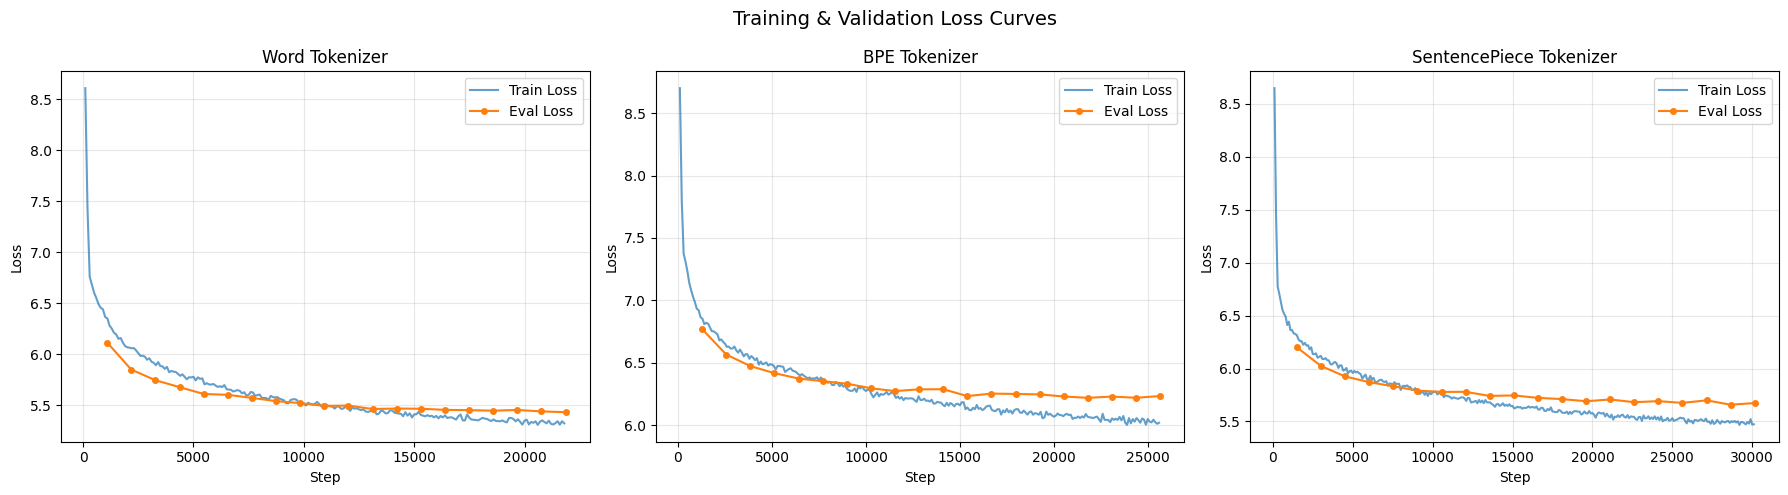

Loss curves saved to genetic_ai_tokenization_project/results/loss_curves.png


In [12]:

word_model_split = build_mlm_model(
    vocab_size=len(word_vocab_split),
    pad_token_id=word2id_split[PAD_TOKEN]
)

bpe_model_split = build_mlm_model(
    vocab_size=bpe_tokenizer_split.vocab_size,
    pad_token_id=bpe_tokenizer_split.pad_token_id
)

sp_model_split = build_mlm_model(
    vocab_size=sp_processor_split.get_piece_size(),
    pad_token_id=sp_processor_split.piece_to_id(PAD_TOKEN)
)

word_trainer_split = build_trainer(
    model=word_model_split,
    train_dataset=word_train_dataset_split,
    eval_dataset=word_valid_dataset_split,
    data_collator=word_collator_split,
    output_dir=MODEL_DIR / "word_model_split_whole_word"
)

bpe_trainer_split = build_trainer(
    model=bpe_model_split,
    train_dataset=bpe_train_dataset_split,
    eval_dataset=bpe_valid_dataset_split,
    data_collator=bpe_collator_split,
    output_dir=MODEL_DIR / "bpe_model_split_whole_word"
)

sp_trainer_split = build_trainer(
    model=sp_model_split,
    train_dataset=sp_train_dataset_split,
    eval_dataset=sp_valid_dataset_split,
    data_collator=sp_collator_split,
    output_dir=MODEL_DIR / "sp_model_split_whole_word"
)

print("Training word MLM model with whole-word masking...")
word_train_result_split = word_trainer_split.train()

print("\nTraining BPE MLM model with whole-word masking...")
bpe_train_result_split = bpe_trainer_split.train()

print("\nTraining SentencePiece MLM model with whole-word masking...")
sp_train_result_split = sp_trainer_split.train()

word_trainer_split.save_model(str(MODEL_DIR / "word_model_split_whole_word_final"))
bpe_trainer_split.save_model(str(MODEL_DIR / "bpe_model_split_whole_word_final"))
sp_trainer_split.save_model(str(MODEL_DIR / "sp_model_split_whole_word_final"))

print("\nWhole-word masking training losses")
print("Word:", word_train_result_split.training_loss)
print("BPE:", bpe_train_result_split.training_loss)
print("SentencePiece:", sp_train_result_split.training_loss)

# Plot training and validation loss curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, trainer) in zip(axes, [
    ("Word", word_trainer_split),
    ("BPE", bpe_trainer_split),
    ("SentencePiece", sp_trainer_split),
]):
    log_history = trainer.state.log_history
    train_steps = [e["step"] for e in log_history if "loss" in e]
    train_losses = [e["loss"] for e in log_history if "loss" in e]
    eval_steps = [e["step"] for e in log_history if "eval_loss" in e]
    eval_losses = [e["eval_loss"] for e in log_history if "eval_loss" in e]

    ax.plot(train_steps, train_losses, label="Train Loss", alpha=0.7)
    ax.plot(eval_steps, eval_losses, label="Eval Loss", marker="o", markersize=4)
    ax.set_title(f"{name} Tokenizer")
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Training & Validation Loss Curves", fontsize=14)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "loss_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Loss curves saved to", RESULTS_DIR / "loss_curves.png")

In [13]:
# Manual evaluation without Trainer.evaluate()


def manual_eval_loss(model, eval_dataset, data_collator, batch_size=16):
    model.eval()
    total_loss = 0.0
    total_batches = 0

    loader = torch.utils.data.DataLoader(
        eval_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=data_collator
    )

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            total_loss += loss.item()
            total_batches += 1

    return total_loss / total_batches if total_batches > 0 else float("nan")

print("Manual validation losses")
print("Word eval loss:", manual_eval_loss(
    word_model_split, word_valid_dataset_split, word_collator_split, batch_size=BATCH_SIZE
))
print("BPE eval loss:", manual_eval_loss(
    bpe_model_split, bpe_valid_dataset_split, bpe_collator_split, batch_size=BATCH_SIZE
))
print("SentencePiece eval loss:", manual_eval_loss(
    sp_model_split, sp_valid_dataset_split, sp_collator_split, batch_size=BATCH_SIZE
))

Manual validation losses
Word eval loss: 5.440461377302806
BPE eval loss: 6.229363843014366
SentencePiece eval loss: 5.686914944067234


In [14]:

from collections import Counter

train_word_tokens = word_tokenize_text(wikitext_train_text)
freq_counter = Counter(train_word_tokens)

print("Rebuilt frequency counter.")
print("Total unique tokens:", len(freq_counter))

Rebuilt frequency counter.
Total unique tokens: 32832


In [15]:
# Evaluation target filtering: keep it cleaner, but do not over-tighten
import nltk
from nltk.corpus import stopwords
import re

try:
    STOPWORDS = set(stopwords.words("english"))
except LookupError:
    nltk.download("stopwords")
    STOPWORDS = set(stopwords.words("english"))

try:
    nltk.data.find("taggers/averaged_perceptron_tagger_eng")
except LookupError:
    nltk.download("averaged_perceptron_tagger_eng")

EXTRA_EXCLUDE = {
    "'s", "n't", "'re", "'ve", "'ll", "'d",
    "said", "one", "two"
}

EVAL_EXCLUDE_WORDS = {w.lower() for w in STOPWORDS}.union(EXTRA_EXCLUDE)

NOISY_EXACT = {"unk", "[unk]", "<unk>"}
HEADER_LIKE = {
    "music", "background", "reception", "union",
    "chapter", "section", "part", "act", "scene", "book", "volume"
}

def is_content_word(word):
    tag = nltk.pos_tag([word])[0][1]
    return tag.startswith(("NN", "VB", "JJ", "RB"))

def is_good_eval_target(word, min_len=3):
    w = word.strip()
    wl = w.lower()

    return (
        w.isalpha()
        and len(w) >= min_len
        and wl not in EVAL_EXCLUDE_WORDS
        and wl not in NOISY_EXACT
        and wl not in HEADER_LIKE
        and not re.fullmatch(r"[ivxlcdm]+", wl)
        and is_content_word(w)
    )

print("Example excluded words:", sorted(list(EVAL_EXCLUDE_WORDS))[:25])

Example excluded words: ["'d", "'ll", "'re", "'s", "'ve", 'a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


In [16]:
# Additional evaluation helpers
import math
import pandas as pd

def reciprocal_rank_from_rank(rank):
    if rank is None or rank <= 0:
        return 0.0
    return 1.0 / rank

In [17]:
# Evaluation helpers: relaxed sample construction + soft metrics

wikitext_valid_lines = [
    line.strip() for line in wikitext_valid_text.split("\n")
    if line.strip()
]

print("WikiText validation lines:", len(wikitext_valid_lines))

def normalize_piece(piece):
    if piece is None:
        return ""
    return piece.replace("Ġ", "").replace("▁", "").strip()

def tokenize_alpha_words(text):
    return [tok for tok in word_tokenize_text(text) if tok.isalpha()]

def is_clean_eval_sentence(sentence, max_upper_ratio=0.6, max_unk_markers=2):
    s = sentence.strip()
    lower_s = s.lower()

    unk_count = lower_s.count("<unk>") + lower_s.count("[unk]") + lower_s.count(" unk ")
    if unk_count > max_unk_markers:
        return False

    tokens = word_tokenize_text(s)
    alpha_tokens = [t for t in tokens if t.isalpha()]
    if len(alpha_tokens) < 5:
        return False

    upper_ratio = sum(1 for t in alpha_tokens if t[0].isupper()) / len(alpha_tokens)
    if upper_ratio > max_upper_ratio:
        return False

    return True

def build_eval_samples_from_lines(lines, candidate_words, max_samples=200, min_tokens=5, min_target_len=3):
    samples = []
    for line in lines:
        if not is_clean_eval_sentence(line):
            continue

        tokens = word_tokenize_text(line)
        if len(tokens) < min_tokens:
            continue

        candidate_targets = [
            tok for tok in tokens
            if tok in candidate_words and is_good_eval_target(tok, min_len=min_target_len)
        ]
        unique_candidates = list(dict.fromkeys(candidate_targets))

        if len(unique_candidates) != 1:
            continue

        target = unique_candidates[0]
        matches = re.findall(rf"\b{re.escape(target)}\b", line)
        if len(matches) != 1:
            continue

        samples.append({
            "sentence": line,
            "target_word": target
        })

    random.seed(SEED)
    random.shuffle(samples)
    return samples[:max_samples]

def find_word_token_index(sentence, target_word):
    tokens = word_tokenize_text(sentence)
    indices = [i for i, tok in enumerate(tokens) if tok == target_word]
    if len(indices) != 1:
        return None, tokens
    return indices[0], tokens

def get_word_topk_predictions(sentence, target_word, k=100):
    idx, tokens = find_word_token_index(sentence, target_word)
    if idx is None:
        return None

    input_ids = [word2id_split.get(tok, word2id_split[UNK_TOKEN]) for tok in tokens]
    input_ids[idx] = word2id_split[MASK_TOKEN]

    input_tensor = torch.tensor([input_ids], dtype=torch.long, device=device)
    attention_mask = torch.ones_like(input_tensor)

    with torch.no_grad():
        outputs = word_model_split(input_ids=input_tensor, attention_mask=attention_mask)
        logits = outputs.logits[0, idx]
        topk_ids = torch.topk(logits, k=k).indices.tolist()

    return [id2word_split[i].strip() for i in topk_ids]

def get_word_single_token_metrics(sentence, target_word, k=100):
    idx, tokens = find_word_token_index(sentence, target_word)
    if idx is None:
        return None

    gold_id = word2id_split.get(target_word)
    if gold_id is None:
        return None

    input_ids = [word2id_split.get(tok, word2id_split[UNK_TOKEN]) for tok in tokens]
    input_ids[idx] = word2id_split[MASK_TOKEN]

    input_tensor = torch.tensor([input_ids], dtype=torch.long, device=device)
    attention_mask = torch.ones_like(input_tensor)

    with torch.no_grad():
        outputs = word_model_split(input_ids=input_tensor, attention_mask=attention_mask)
        logits = outputs.logits[0, idx]
        probs = torch.softmax(logits, dim=-1)
        sorted_ids = torch.argsort(logits, descending=True)
        rank = int((sorted_ids == gold_id).nonzero(as_tuple=True)[0][0].item()) + 1
        topk_ids = torch.topk(logits, k=k).indices.tolist()

    return {
        "topk": [id2word_split[i].strip() for i in topk_ids],
        "rank": rank,
        "mrr": 1.0 / rank,
        "target_prob": float(probs[gold_id].item()),
        "top1": gold_id in topk_ids[:1],
        "top5": gold_id in topk_ids[:5],
        "top10": gold_id in topk_ids[:10],
        "top50": gold_id in topk_ids[:50],
        "top100": gold_id in topk_ids[:100],
    }

def get_bpe_word_spans(sentence):
    enc = bpe_tokenizer_split(
        sentence,
        add_special_tokens=False,
        return_offsets_mapping=True
    )
    input_ids = enc["input_ids"]
    offsets = enc["offset_mapping"]
    tokens = bpe_tokenizer_split.convert_ids_to_tokens(input_ids)

    spans = []
    current = []

    for i, tok in enumerate(tokens):
        start, end = offsets[i]
        if start == end:
            if current:
                spans.append(current)
                current = []
            continue

        is_new_word = tok.startswith("Ġ") or i == 0
        clean_tok = normalize_piece(tok)

        if is_new_word:
            if current:
                spans.append(current)
            current = [i] if clean_tok.isalpha() else []
        else:
            if current and clean_tok.isalpha():
                current.append(i)
            else:
                if current:
                    spans.append(current)
                current = []

    if current:
        spans.append(current)

    return input_ids, offsets, tokens, spans

def decode_bpe_span(input_ids, span):
    return bpe_tokenizer_split.decode([input_ids[i] for i in span]).strip()

def find_bpe_target_span(sentence, target_word, single_token_only=False):
    input_ids, offsets, tokens, spans = get_bpe_word_spans(sentence)
    matches = []

    for span in spans:
        decoded = decode_bpe_span(input_ids, span)
        if decoded == target_word:
            if (not single_token_only) or len(span) == 1:
                matches.append(span)

    if len(matches) != 1:
        return None, input_ids

    return matches[0], input_ids

def get_bpe_topk_predictions_single(sentence, target_word, k=100):
    span, input_ids = find_bpe_target_span(sentence, target_word, single_token_only=True)
    if span is None:
        return None

    idx = span[0]
    masked_ids = list(input_ids)
    masked_ids[idx] = bpe_tokenizer_split.mask_token_id

    input_tensor = torch.tensor([masked_ids], dtype=torch.long, device=device)
    attention_mask = torch.ones_like(input_tensor)

    with torch.no_grad():
        outputs = bpe_model_split(input_ids=input_tensor, attention_mask=attention_mask)
        logits = outputs.logits[0, idx]
        topk_ids = torch.topk(logits, k=k).indices.tolist()

    return [bpe_tokenizer_split.decode([i]).strip() for i in topk_ids]

def get_bpe_single_token_metrics(sentence, target_word, k=100):
    span, input_ids = find_bpe_target_span(sentence, target_word, single_token_only=True)
    if span is None:
        return None

    idx = span[0]
    gold_id = input_ids[idx]

    masked_ids = list(input_ids)
    masked_ids[idx] = bpe_tokenizer_split.mask_token_id

    input_tensor = torch.tensor([masked_ids], dtype=torch.long, device=device)
    attention_mask = torch.ones_like(input_tensor)

    with torch.no_grad():
        outputs = bpe_model_split(input_ids=input_tensor, attention_mask=attention_mask)
        logits = outputs.logits[0, idx]
        probs = torch.softmax(logits, dim=-1)
        sorted_ids = torch.argsort(logits, descending=True)
        rank = int((sorted_ids == gold_id).nonzero(as_tuple=True)[0][0].item()) + 1
        topk_ids = torch.topk(logits, k=k).indices.tolist()

    return {
        "topk": [bpe_tokenizer_split.decode([i]).strip() for i in topk_ids],
        "rank": rank,
        "mrr": 1.0 / rank,
        "target_prob": float(probs[gold_id].item()),
        "top1": gold_id in topk_ids[:1],
        "top5": gold_id in topk_ids[:5],
        "top10": gold_id in topk_ids[:10],
        "top50": gold_id in topk_ids[:50],
        "top100": gold_id in topk_ids[:100],
    }

def get_sp_word_spans(sentence):
    pieces = sp_processor_split.encode(sentence, out_type=str)
    ids = sp_processor_split.encode(sentence, out_type=int)

    spans = []
    current = []

    for i, piece in enumerate(pieces):
        clean_piece = normalize_piece(piece)
        is_new_word = piece.startswith("▁") or i == 0

        if is_new_word:
            if current:
                spans.append(current)
            current = [i] if clean_piece.isalpha() else []
        else:
            if current and clean_piece.isalpha():
                current.append(i)
            else:
                if current:
                    spans.append(current)
                current = []

    if current:
        spans.append(current)

    return ids, pieces, spans

def decode_sp_span(ids, span):
    return sp_processor_split.decode([ids[i] for i in span]).strip()

def find_sp_target_span(sentence, target_word, single_token_only=False):
    input_ids, pieces, spans = get_sp_word_spans(sentence)
    matches = []

    for span in spans:
        decoded = decode_sp_span(input_ids, span)
        if decoded == target_word:
            if (not single_token_only) or len(span) == 1:
                matches.append(span)

    if len(matches) != 1:
        return None, input_ids

    return matches[0], input_ids

def get_sp_topk_predictions_single(sentence, target_word, k=100):
    span, input_ids = find_sp_target_span(sentence, target_word, single_token_only=True)
    if span is None:
        return None

    idx = span[0]
    masked_ids = list(input_ids)
    masked_ids[idx] = sp_processor_split.piece_to_id(MASK_TOKEN)

    input_tensor = torch.tensor([masked_ids], dtype=torch.long, device=device)
    attention_mask = torch.ones_like(input_tensor)

    with torch.no_grad():
        outputs = sp_model_split(input_ids=input_tensor, attention_mask=attention_mask)
        logits = outputs.logits[0, idx]
        topk_ids = torch.topk(logits, k=k).indices.tolist()

    return [
        sp_processor_split.id_to_piece(i).replace("▁", "").strip()
        for i in topk_ids
    ]

def get_sp_single_token_metrics(sentence, target_word, k=100):
    span, input_ids = find_sp_target_span(sentence, target_word, single_token_only=True)
    if span is None:
        return None

    idx = span[0]
    gold_id = input_ids[idx]

    masked_ids = list(input_ids)
    masked_ids[idx] = sp_processor_split.piece_to_id(MASK_TOKEN)

    input_tensor = torch.tensor([masked_ids], dtype=torch.long, device=device)
    attention_mask = torch.ones_like(input_tensor)

    with torch.no_grad():
        outputs = sp_model_split(input_ids=input_tensor, attention_mask=attention_mask)
        logits = outputs.logits[0, idx]
        probs = torch.softmax(logits, dim=-1)
        sorted_ids = torch.argsort(logits, descending=True)
        rank = int((sorted_ids == gold_id).nonzero(as_tuple=True)[0][0].item()) + 1
        topk_ids = torch.topk(logits, k=k).indices.tolist()

    return {
        "topk": [sp_processor_split.id_to_piece(i).replace("▁", "").strip() for i in topk_ids],
        "rank": rank,
        "mrr": 1.0 / rank,
        "target_prob": float(probs[gold_id].item()),
        "top1": gold_id in topk_ids[:1],
        "top5": gold_id in topk_ids[:5],
        "top10": gold_id in topk_ids[:10],
        "top50": gold_id in topk_ids[:50],
        "top100": gold_id in topk_ids[:100],
    }

def reconstruct_bpe_prediction(sentence, target_word):
    span, input_ids = find_bpe_target_span(sentence, target_word, single_token_only=False)
    if span is None:
        return None

    masked_ids = list(input_ids)
    for idx in span:
        masked_ids[idx] = bpe_tokenizer_split.mask_token_id

    input_tensor = torch.tensor([masked_ids], dtype=torch.long, device=device)
    attention_mask = torch.ones_like(input_tensor)

    with torch.no_grad():
        outputs = bpe_model_split(input_ids=input_tensor, attention_mask=attention_mask)
        logits = outputs.logits[0]

    pred_ids = []
    gold_ids = [input_ids[i] for i in span]
    for idx in span:
        pred_ids.append(int(torch.argmax(logits[idx]).item()))

    pred_word = bpe_tokenizer_split.decode(pred_ids).strip()
    gold_word = bpe_tokenizer_split.decode(gold_ids).strip()

    piece_acc = sum(int(p == g) for p, g in zip(pred_ids, gold_ids)) / len(gold_ids)

    return {
        "pred_word": pred_word,
        "gold_word": gold_word,
        "piece_accuracy": piece_acc,
        "n_pieces": len(span),
        "exact_match": pred_word == gold_word
    }

def reconstruct_sp_prediction(sentence, target_word):
    span, input_ids = find_sp_target_span(sentence, target_word, single_token_only=False)
    if span is None:
        return None

    masked_ids = list(input_ids)
    mask_id = sp_processor_split.piece_to_id(MASK_TOKEN)
    for idx in span:
        masked_ids[idx] = mask_id

    input_tensor = torch.tensor([masked_ids], dtype=torch.long, device=device)
    attention_mask = torch.ones_like(input_tensor)

    with torch.no_grad():
        outputs = sp_model_split(input_ids=input_tensor, attention_mask=attention_mask)
        logits = outputs.logits[0]

    pred_ids = []
    gold_ids = [input_ids[i] for i in span]
    for idx in span:
        pred_ids.append(int(torch.argmax(logits[idx]).item()))

    pred_word = sp_processor_split.decode(pred_ids).strip()
    gold_word = sp_processor_split.decode(gold_ids).strip()
    piece_acc = sum(int(p == g) for p, g in zip(pred_ids, gold_ids)) / len(gold_ids)

    return {
        "pred_word": pred_word,
        "gold_word": gold_word,
        "piece_accuracy": piece_acc,
        "n_pieces": len(span),
        "exact_match": pred_word == gold_word
    }


def get_word_multitoken_metrics(sentence, target_word, k=100):
    """Word tokenizer: always single-token, so same as single-token metrics."""
    return get_word_single_token_metrics(sentence, target_word, k=k)

def get_bpe_multitoken_metrics(sentence, target_word, k=100):
    """BPE: evaluate ANY word (single or multi-token) by masking all pieces and checking reconstruction."""
    span, input_ids = find_bpe_target_span(sentence, target_word, single_token_only=False)
    if span is None:
        return None

    if len(span) == 1:
        # Single token - use standard metrics
        return get_bpe_single_token_metrics(sentence, target_word, k=k)

    # Multi-token: mask all pieces, predict independently, check exact match
    gold_ids = [input_ids[i] for i in span]
    masked_ids = list(input_ids)
    for idx in span:
        masked_ids[idx] = bpe_tokenizer_split.mask_token_id

    input_tensor = torch.tensor([masked_ids], dtype=torch.long, device=device)
    attention_mask = torch.ones_like(input_tensor)

    with torch.no_grad():
        outputs = bpe_model_split(input_ids=input_tensor, attention_mask=attention_mask)

    # Check exact reconstruction
    pred_ids = [int(torch.argmax(outputs.logits[0, idx]).item()) for idx in span]
    pred_word = bpe_tokenizer_split.decode(pred_ids).strip()
    piece_acc = sum(int(p == g) for p, g in zip(pred_ids, gold_ids)) / len(gold_ids)
    exact_match = pred_word == target_word

    # For multi-token, rank/MRR don't have a clean single-value analog,
    # so we report piece accuracy and exact match via the top-k fields
    return {
        "topk": [pred_word],
        "rank": None,
        "mrr": None,
        "target_prob": None,
        "top1": exact_match,
        "top5": exact_match,
        "top10": exact_match,
        "top50": exact_match,
        "top100": exact_match,
        "piece_accuracy": piece_acc,
        "n_pieces": len(span),
        "is_multitoken": True,
    }

def get_sp_multitoken_metrics(sentence, target_word, k=100):
    """SentencePiece: evaluate ANY word (single or multi-token) by masking all pieces."""
    span, input_ids = find_sp_target_span(sentence, target_word, single_token_only=False)
    if span is None:
        return None

    if len(span) == 1:
        return get_sp_single_token_metrics(sentence, target_word, k=k)

    # Multi-token: mask all pieces
    gold_ids = [input_ids[i] for i in span]
    mask_id = sp_processor_split.piece_to_id(MASK_TOKEN)
    masked_ids = list(input_ids)
    for idx in span:
        masked_ids[idx] = mask_id

    input_tensor = torch.tensor([masked_ids], dtype=torch.long, device=device)
    attention_mask = torch.ones_like(input_tensor)

    with torch.no_grad():
        outputs = sp_model_split(input_ids=input_tensor, attention_mask=attention_mask)

    pred_ids = [int(torch.argmax(outputs.logits[0, idx]).item()) for idx in span]
    pred_word = sp_processor_split.decode(pred_ids).strip()
    piece_acc = sum(int(p == g) for p, g in zip(pred_ids, gold_ids)) / len(gold_ids)
    exact_match = pred_word == target_word

    return {
        "topk": [pred_word],
        "rank": None,
        "mrr": None,
        "target_prob": None,
        "top1": exact_match,
        "top5": exact_match,
        "top10": exact_match,
        "top50": exact_match,
        "top100": exact_match,
        "piece_accuracy": piece_acc,
        "n_pieces": len(span),
        "is_multitoken": True,
    }

def evaluate_unified(eval_samples, k_values=(1, 5, 10, 50, 100)):
    """Unified evaluation: uses ALL words (single + multi-token) for fair cross-tokenizer comparison.
    For single-token words, standard rank-based metrics are used.
    For multi-token words, exact-match reconstruction is used.
    """
    metric_getters = {
        "word": get_word_multitoken_metrics,
        "bpe": get_bpe_multitoken_metrics,
        "sentencepiece": get_sp_multitoken_metrics,
    }

    rows = []
    summary_rows = []

    for name, getter in metric_getters.items():
        usable = 0
        single_token_count = 0
        multi_token_count = 0
        top_hits = {k: 0 for k in k_values}
        mrr_sum = 0.0
        rank_sum = 0.0
        rank_count = 0
        prob_sum = 0.0
        piece_acc_sum = 0.0

        for item in eval_samples:
            sentence = item["sentence"]
            target = item["target_word"]
            metrics = getter(sentence, target, k=max(k_values))
            if metrics is None:
                continue

            usable += 1
            is_multi = metrics.get("is_multitoken", False)
            if is_multi:
                multi_token_count += 1
            else:
                single_token_count += 1

            for k in k_values:
                top_hits[k] += int(metrics[f"top{k}"])

            if metrics["mrr"] is not None:
                mrr_sum += metrics["mrr"]
                rank_sum += metrics["rank"]
                rank_count += 1
            if metrics["target_prob"] is not None:
                prob_sum += metrics["target_prob"]

            piece_acc = metrics.get("piece_accuracy", 1.0 if metrics.get("top1") else 0.0)
            piece_acc_sum += piece_acc

            rows.append({
                "tokenizer": name,
                "sentence": sentence,
                "target_word": target,
                "rank": metrics["rank"],
                "mrr": metrics["mrr"],
                "target_prob": metrics["target_prob"],
                "top1": metrics["top1"],
                "top5": metrics["top5"],
                "top10": metrics["top10"],
                "top50": metrics["top50"],
                "top100": metrics["top100"],
                "top_predictions": metrics["topk"],
                "is_multitoken": is_multi,
                "n_pieces": metrics.get("n_pieces", 1),
                "piece_accuracy": piece_acc,
            })

        summary_row = {
            "tokenizer": name,
            "usable_examples": usable,
            "single_token": single_token_count,
            "multi_token": multi_token_count,
            "mrr": mrr_sum / rank_count if rank_count else None,
            "mean_rank": rank_sum / rank_count if rank_count else None,
            "mean_target_prob": prob_sum / rank_count if rank_count else None,
            "mean_piece_accuracy": piece_acc_sum / usable if usable else 0.0,
        }
        for k in k_values:
            summary_row[f"top{k}"] = top_hits[k] / usable if usable else 0.0
        summary_rows.append(summary_row)

    return pd.DataFrame(summary_rows), pd.DataFrame(rows)


def evaluate_single_token_soft(eval_samples, k_values=(1, 5, 10, 50, 100)):
    metric_getters = {
        "word": get_word_single_token_metrics,
        "bpe": get_bpe_single_token_metrics,
        "sentencepiece": get_sp_single_token_metrics,
    }

    rows = []
    summary_rows = []

    for name, getter in metric_getters.items():
        usable = 0
        top_hits = {k: 0 for k in k_values}
        mrr_sum = 0.0
        rank_sum = 0.0
        prob_sum = 0.0

        for item in eval_samples:
            sentence = item["sentence"]
            target = item["target_word"]
            metrics = getter(sentence, target, k=max(k_values))
            if metrics is None:
                continue

            usable += 1
            for k in k_values:
                top_hits[k] += int(metrics[f"top{k}"])
            mrr_sum += metrics["mrr"]
            rank_sum += metrics["rank"]
            prob_sum += metrics["target_prob"]

            rows.append({
                "tokenizer": name,
                "sentence": sentence,
                "target_word": target,
                "rank": metrics["rank"],
                "mrr": metrics["mrr"],
                "target_prob": metrics["target_prob"],
                "top1": metrics["top1"],
                "top5": metrics["top5"],
                "top10": metrics["top10"],
                "top50": metrics["top50"],
                "top100": metrics["top100"],
                "top_predictions": metrics["topk"],
            })

        summary_row = {
            "tokenizer": name,
            "usable_examples": usable,
            "mrr": mrr_sum / usable if usable else 0.0,
            "mean_rank": rank_sum / usable if usable else 0.0,
            "mean_target_prob": prob_sum / usable if usable else 0.0,
        }
        for k in k_values:
            summary_row[f"top{k}"] = top_hits[k] / usable if usable else 0.0
        summary_rows.append(summary_row)

    return pd.DataFrame(summary_rows), pd.DataFrame(rows)

def evaluate_reconstruction(eval_samples):
    rows = []

    for item in eval_samples:
        sentence = item["sentence"]
        target = item["target_word"]

        word_pred = get_word_topk_predictions(sentence, target, k=1)
        word_exact = None if word_pred is None else (word_pred[0] == target)

        bpe_recon = reconstruct_bpe_prediction(sentence, target)
        sp_recon = reconstruct_sp_prediction(sentence, target)

        rows.append({
            "sentence": sentence,
            "target_word": target,
            "word_exact_match": word_exact,
            "bpe_exact_match": None if bpe_recon is None else bpe_recon["exact_match"],
            "bpe_piece_accuracy": None if bpe_recon is None else bpe_recon["piece_accuracy"],
            "bpe_n_pieces": None if bpe_recon is None else bpe_recon["n_pieces"],
            "bpe_pred_word": None if bpe_recon is None else bpe_recon["pred_word"],
            "sp_exact_match": None if sp_recon is None else sp_recon["exact_match"],
            "sp_piece_accuracy": None if sp_recon is None else sp_recon["piece_accuracy"],
            "sp_n_pieces": None if sp_recon is None else sp_recon["n_pieces"],
            "sp_pred_word": None if sp_recon is None else sp_recon["pred_word"],
        })

    if len(rows) == 0:
        empty_summary = pd.DataFrame([
            {"tokenizer": "word", "usable_examples": 0, "exact_match": 0.0, "avg_piece_accuracy": 0.0},
            {"tokenizer": "bpe", "usable_examples": 0, "exact_match": 0.0, "avg_piece_accuracy": 0.0},
            {"tokenizer": "sentencepiece", "usable_examples": 0, "exact_match": 0.0, "avg_piece_accuracy": 0.0},
        ])
        empty_details = pd.DataFrame(columns=[
            "sentence", "target_word", "word_exact_match",
            "bpe_exact_match", "bpe_piece_accuracy", "bpe_n_pieces", "bpe_pred_word",
            "sp_exact_match", "sp_piece_accuracy", "sp_n_pieces", "sp_pred_word"
        ])
        return empty_summary, empty_details

    df = pd.DataFrame(rows)

    summary = pd.DataFrame([
        {
            "tokenizer": "word",
            "usable_examples": int(df["word_exact_match"].notna().sum()),
            "exact_match": float(df["word_exact_match"].dropna().mean()) if df["word_exact_match"].notna().sum() > 0 else 0.0,
            "avg_piece_accuracy": float(df["word_exact_match"].dropna().mean()) if df["word_exact_match"].notna().sum() > 0 else 0.0,
        },
        {
            "tokenizer": "bpe",
            "usable_examples": int(df["bpe_exact_match"].notna().sum()),
            "exact_match": float(df["bpe_exact_match"].dropna().mean()) if df["bpe_exact_match"].notna().sum() > 0 else 0.0,
            "avg_piece_accuracy": float(df["bpe_piece_accuracy"].dropna().mean()) if df["bpe_piece_accuracy"].notna().sum() > 0 else 0.0,
        },
        {
            "tokenizer": "sentencepiece",
            "usable_examples": int(df["sp_exact_match"].notna().sum()),
            "exact_match": float(df["sp_exact_match"].dropna().mean()) if df["sp_exact_match"].notna().sum() > 0 else 0.0,
            "avg_piece_accuracy": float(df["sp_piece_accuracy"].dropna().mean()) if df["sp_piece_accuracy"].notna().sum() > 0 else 0.0,
        },
    ])

    return summary, df

# Frequent content words from WikiText train
train_word_tokens = word_tokenize_text(wikitext_train_text)
freq_counter = Counter(train_word_tokens)

frequent_words = [
    word for word, freq in freq_counter.items()
    if freq >= 100
    and is_good_eval_target(word, min_len=3)
    # No vocab filter — each tokenizer handles unknown words independently
]

print("Frequent content-word targets:", len(frequent_words))
print("Sample frequent content words:", frequent_words[:20])

wikitext_frequent_eval_samples = build_eval_samples_from_lines(
    wikitext_valid_lines,
    frequent_words,
    max_samples=200,
    min_target_len=3
)

print("Selected frequent-word eval samples:", len(wikitext_frequent_eval_samples))
frequent_soft_summary, frequent_soft_details = evaluate_single_token_soft(wikitext_frequent_eval_samples)

print("\nFrequent content-word benchmark (soft metrics)")
display(frequent_soft_summary)
display(frequent_soft_details.head(10))

WikiText validation lines: 2461
Frequent content-word targets: 1748
Sample frequent content words: ['Japanese', 'commonly', 'referred', 'Japan', 'role', 'playing', 'video', 'game', 'developed', 'PlayStation', 'January', 'third', 'series', 'real', 'time', 'story', 'runs', 'first', 'follows', 'military']
Selected frequent-word eval samples: 40

Frequent content-word benchmark (soft metrics)


,tokenizer,usable_examples,mrr,mean_rank,mean_target_prob,top1,top5,top10,top50,top100
0,word,40,0.005432,760.975000,0.000653,0.0,0.0,0.0,0.050000,0.225000
1,bpe,39,0.002134,1562.435897,0.000297,0.0,0.0,0.0,0.000000,0.025641
2,sentencepiece,29,0.005800,813.620690,0.000769,0.0,0.0,0.0,0.034483,0.206897


,tokenizer,sentence,target_word,rank,mrr,target_prob,top1,top5,top10,top50,top100,top_predictions
0,word,= = = Rise of Tai @-@ Shan states = = =,states,1302,0.000768,0.000135,False,False,False,False,False,"[of, the, and, The, a, ft, is, C, in, are, wit..."
1,word,"<unk> Ward was born in Meridian , in 1956 .",born,318,0.003145,0.000387,False,False,False,False,False,"[in, the, and, The, was, of, a, by, as, s, for..."
2,word,= Battle of <unk> 's Ridge =,Battle,2511,0.000398,0.000027,False,False,False,False,False,"[s, unk, Ridge, the, of, to, and, Bolton, feet..."
3,word,"<unk> Pike as Miranda Frost , undercover MI6 a...",double,273,0.003663,0.000461,False,False,False,False,False,"[and, the, agent, of, as, a, in, by, with, to,..."
4,word,"= = = Military intervention against <unk> , 20...",present,1440,0.000694,0.000071,False,False,False,False,False,"[unk, the, of, and, was, in, a, to, military, ..."
5,word,"= = = Defence of Australia , 1980s and 1990s =...",Australia,130,0.007692,0.001017,False,False,False,False,False,"[s, the, of, and, was, in, a, The, Defence, as..."
6,word,Charlie Day as Dale <unk>,Day,159,0.006289,0.000581,False,False,False,False,False,"[unk, Charlie, the, to, and, a, is, in, on, of..."
7,word,"= = = Operation <unk> ; the "" Green Leader "" r...",Operation,98,0.010204,0.001018,False,False,False,False,True,"[unk, the, of, and, on, in, a, was, The, that,..."
8,word,Susan <unk> who won the Miss America beauty pa...,America,368,0.002717,0.000323,False,False,False,False,False,"[the, in, unk, and, a, of, by, Miss, s, was, T..."
9,word,"<unk> , and other charges , testified in assas...",case,225,0.004444,0.000547,False,False,False,False,False,"[the, and, of, who, to, assassination, a, in, ..."


In [18]:
# WIKITEXT MEDIUM-FREQUENCY CONTENT-WORD BENCHMARK + RARE-WORD EVALUATION

from nltk.tokenize import sent_tokenize
from collections import Counter

train_word_tokens = word_tokenize_text(wikitext_train_text)
freq_counter = Counter(train_word_tokens)

medium_words = {
    word for word, freq in freq_counter.items()
    if 20 <= freq <= 50
    and is_good_eval_target(word, min_len=4)
    # No vocab filter — each tokenizer handles unknown words independently
}

rare_words = {
    word for word, freq in freq_counter.items()
    if RARE_WORD_MIN_FREQ <= freq <= RARE_WORD_MAX_FREQ
    and is_good_eval_target(word, min_len=4)
    # No vocab filter — each tokenizer handles unknown words independently
}

print("Medium-frequency content words from WikiText train:", len(medium_words))
print("Rare words from WikiText train:", len(rare_words))

wikitext_sentences = sent_tokenize(wikitext_valid_text)
print("WikiText validation sentences:", len(wikitext_sentences))

wiki_medium_eval_samples = build_eval_samples_from_lines(
    wikitext_sentences,
    medium_words,
    max_samples=400,
    min_target_len=4
)

wiki_rare_eval_samples = build_eval_samples_from_lines(
    wikitext_sentences,
    rare_words,
    max_samples=500,
    min_target_len=4
)

print("Selected Wiki medium-frequency eval samples:", len(wiki_medium_eval_samples))
print("Selected Wiki rare-word eval samples:", len(wiki_rare_eval_samples))

for label, samples in [("Medium", wiki_medium_eval_samples), ("Rare", wiki_rare_eval_samples)]:
    for i in range(min(3, len(samples))):
        print(f"\n{label} Example {i+1}")
        print("Sentence:", samples[i]["sentence"])
        print("Target:", samples[i]["target_word"])

wiki_medium_soft_summary, wiki_medium_soft_details = evaluate_single_token_soft(wiki_medium_eval_samples)
wiki_rare_soft_summary, wiki_rare_soft_details = evaluate_single_token_soft(wiki_rare_eval_samples)
wiki_recon_summary, wiki_recon_details = evaluate_reconstruction(wiki_rare_eval_samples)

# Unified evaluation (fair cross-tokenizer comparison using ALL words)
wiki_medium_unified_summary, wiki_medium_unified_details = evaluate_unified(wiki_medium_eval_samples)
wiki_rare_unified_summary, wiki_rare_unified_details = evaluate_unified(wiki_rare_eval_samples)

print("\nWiki medium-frequency content-word benchmark (soft metrics)")
display(wiki_medium_soft_summary)

print("\nWiki rare-word single-token benchmark (soft metrics)")
display(wiki_rare_soft_summary)

print("\nWiki rare-word tokenizer-aware reconstruction")
display(wiki_recon_summary)

print("\n=== UNIFIED EVALUATION (all words, fair cross-tokenizer comparison) ===")
print("\nWiki medium-frequency unified (single + multi-token):")
display(wiki_medium_unified_summary)

print("\nWiki rare-word unified (single + multi-token):")
display(wiki_rare_unified_summary)

display(wiki_medium_soft_details.head(10))
display(wiki_rare_soft_details.head(10))
display(wiki_recon_details.head(10))

Medium-frequency content words from WikiText train: 4161
Rare words from WikiText train: 16906
WikiText validation sentences: 8224
Selected Wiki medium-frequency eval samples: 400
Selected Wiki rare-word eval samples: 500

Medium Example 1
Sentence: The five members of the city council are elected every four years from each of the city 's five wards , considered single @-@ member districts .
Target: districts

Medium Example 2
Sentence: However , Allied estimates of Japanese strength were later found to be grossly inaccurate and after the war it was found that the number of Japanese on the island at this time was closer to 40 @,@ 000 .
Target: estimates

Medium Example 3
Sentence: The structure is a single @-@ span , pin @-@ connected , <unk> , through @-@ <unk> bridge , and it is the only known example of its type in Michigan .
Target: span

Rare Example 1
Sentence: The Carnegie Branch Library , now demolished , was one of a number of Carnegie libraries built for blacks in the Souther

,tokenizer,usable_examples,mrr,mean_rank,mean_target_prob,top1,top5,top10,top50,top100
0,word,356,0.002221,2137.505618,0.000272,0.0,0.0,0.002809,0.019663,0.036517
1,bpe,24,0.000838,2542.208333,0.000090,0.0,0.0,0.000000,0.000000,0.000000
2,sentencepiece,140,0.001434,1843.050000,0.000137,0.0,0.0,0.000000,0.000000,0.014286



Wiki rare-word single-token benchmark (soft metrics)


,tokenizer,usable_examples,mrr,mean_rank,mean_target_prob,top1,top5,top10,top50,top100
0,word,0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,bpe,1,0.000470,2129.000000,0.000035,0.0,0.0,0.0,0.0,0.0
2,sentencepiece,19,0.000934,2273.421053,0.000069,0.0,0.0,0.0,0.0,0.0



Wiki rare-word tokenizer-aware reconstruction


...


Wiki rare-word unified (single + multi-token):


,tokenizer,usable_examples,single_token,multi_token,mrr,mean_rank,mean_target_prob,mean_piece_accuracy,top1,top5,top10,top50,top100
0,word,0,0,0,NaN,NaN,NaN,0.000000,0.0,0.0,0.0,0.0,0.0
1,bpe,500,1,499,0.000470,2129.000000,0.000035,0.001567,0.0,0.0,0.0,0.0,0.0
2,sentencepiece,450,19,431,0.000934,2273.421053,0.000069,0.012259,0.0,0.0,0.0,0.0,0.0


,tokenizer,sentence,target_word,rank,mrr,target_prob,top1,top5,top10,top50,top100,top_predictions
0,word,The five members of the city council are elect...,districts,2327,0.000430,0.000034,False,False,False,False,False,"[the, city, of, and, are, in, The, s, to, a, r..."
1,word,"However , Allied estimates of Japanese strengt...",estimates,2254,0.000444,0.000048,False,False,False,False,False,"[the, to, was, of, it, in, and, a, were, be, t..."
2,word,"The structure is a single @-@ span , pin @-@ c...",span,533,0.001876,0.000249,False,False,False,False,False,"[the, unk, is, of, a, and, in, as, The, to, it..."
3,word,Yorkshire had been criticised in the press for...,Yorkshire,2928,0.000342,0.000028,False,False,False,False,False,"[the, had, to, of, was, a, and, in, unk, that,..."
4,word,Mount <unk> is therefore often referred to as ...,Mountains,34,0.029412,0.002623,False,False,False,True,True,"[the, of, and, as, to, is, a, that, The, in, a..."
5,word,<unk> became almost fully devoid of any convec...,barely,1023,0.000978,0.000054,False,False,False,False,False,"[the, of, a, to, storm, and, on, tropical, km,..."
6,word,Blythe testified that when he wanted to see th...,terrible,2294,0.000436,0.000032,False,False,False,False,False,"[the, to, s, a, was, of, and, that, in, it, he..."
7,word,"However , any Japanese ship remaining within t...",danger,1323,0.000756,0.000080,False,False,False,False,False,"[the, of, to, in, and, aircraft, was, The, a, ..."
8,word,"However , the convection decreased once more a...",decreased,749,0.001335,0.000121,False,False,False,False,False,"[the, of, to, a, into, unk, and, low, on, day,..."
9,word,The elevation gain is not evenly distributed o...,elevation,4855,0.000206,0.000005,False,False,False,False,False,"[the, is, of, a, million, to, in, The, it, be,..."


,tokenizer,sentence,target_word,rank,mrr,target_prob,top1,top5,top10,top50,top100,top_predictions
0,bpe,<unk> received a seven figure salary for the l...,invest,2129,0.000470,0.000035,False,False,False,False,False,"[the, to, his, he, that, a, of, was, and, in, ..."
1,sentencepiece,<unk> was initially taken to a nearby hospital...,kilometer,3013,0.000332,0.000012,False,False,False,False,False,"[the, to, a, and, was, of, in, at, ed, with, f..."
2,sentencepiece,The brigade 's third battalion — the 57th / 60...,dispatch,1000,0.001000,0.000062,False,False,False,False,False,"[the, of, and, Battalion, to, was, in, were, e..."
3,sentencepiece,"In December 2012 , the National Park Service a...",Twin,3570,0.000280,0.000006,False,False,False,False,False,"[the, of, and, in, The, s, River, Historic, on..."
4,sentencepiece,Williams won the encounter after performing hi...,maneuver,2672,0.000374,0.000019,False,False,False,False,False,"[the, of, and, to, a, in, on, his, at, ing, Th..."
5,sentencepiece,The committee concluded that the allegation wa...,allegation,2024,0.000494,0.000028,False,False,False,False,False,"[the, of, that, to, a, and, ed, in, was, The, ..."
6,sentencepiece,Victoria was subsequently used for patrol duti...,logistic,635,0.001575,0.000115,False,False,False,False,False,"[the, and, of, to, in, was, a, were, ed, s, by..."
7,sentencepiece,"In addition , a further 800 Australian logisti...",logistic,4536,0.000220,0.000003,False,False,False,False,False,"[the, and, of, in, s, to, at, a, The, ed, is, ..."
8,sentencepiece,"@ 5 mi ) radius of the site core , peak popula...",kilometer,169,0.005917,0.000574,False,False,False,False,False,"[is, of, km, the, and, in, at, a, to, s, The, ..."
9,sentencepiece,"By 22 May , although there were still a number...",harass,3717,0.000269,0.000004,False,False,False,False,False,"[the, of, and, to, were, in, ed, s, was, a, fo..."


,sentence,target_word,word_exact_match,bpe_exact_match,bpe_piece_accuracy,bpe_n_pieces,bpe_pred_word,sp_exact_match,sp_piece_accuracy,sp_n_pieces,sp_pred_word
0,"The Carnegie Branch Library , now demolished ,...",segregation,False,False,0.0,3,the the the,None,NaN,NaN,None
1,"He also tried a case against <unk> <unk> , an ...",mafia,False,False,0.0,3,the the the,None,NaN,NaN,None
2,<unk> in favor of slavery soon moved to Kansas...,sway,False,False,0.0,2,the the,None,NaN,NaN,None
3,It echoed similar parallels drawn by the Churc...,lobbying,False,False,0.0,3,the the the,False,0.0,3.0,the the the
4,As most religions seek to widen their influenc...,widen,False,False,0.0,2,the the,False,0.0,2.0,the the
5,"Dutch Ceylon , the Dutch Cape Colony and parts...",Ceylon,False,False,0.0,4,the the the the,False,0.0,5.0,the the the the the
6,The frigates subsequently scouted <unk> before...,scouted,False,False,0.0,3,oTT,False,0.5,2.0,eded
7,Asahi was fitted with a <unk> wooden main batt...,Asahi,False,False,0.0,4,the the the the,False,0.0,3.0,the the the
8,<unk> 's script was bought by New Line Cinema ...,Cinema,False,False,0.0,3,the the the,False,0.0,3.0,the the the
9,The series began in 1962 with Sean Connery sta...,Connery,False,False,0.0,3,the the the,None,NaN,NaN,None


In [19]:
# SHAKESPEARE RARE-WORD EVALUATION (OPTIONAL DOMAIN-SHIFT CHECK)

shakespeare_valid_lines = [
    line.strip() for line in shakespeare_valid_text.split("\n")
    if line.strip()
]

print("Shakespeare validation lines:", len(shakespeare_valid_lines))

train_word_tokens = word_tokenize_text(shakespeare_train_text)
freq_counter = Counter(train_word_tokens)

rare_words = {
    word for word, freq in freq_counter.items()
    if RARE_WORD_MIN_FREQ <= freq <= RARE_WORD_MAX_FREQ
    and is_good_eval_target(word, min_len=4)
    # No vocab filter — each tokenizer handles unknown words independently
}

print("Rare words from Shakespeare train:", len(rare_words))

shakespeare_rare_eval_samples = build_eval_samples_from_lines(
    shakespeare_valid_lines,
    rare_words,
    max_samples=500,
    min_target_len=4
)

print("Selected Shakespeare rare-word eval samples:", len(shakespeare_rare_eval_samples))
for i in range(min(5, len(shakespeare_rare_eval_samples))):
    print(f"\nExample {i+1}")
    print("Sentence:", shakespeare_rare_eval_samples[i]["sentence"])
    print("Target:", shakespeare_rare_eval_samples[i]["target_word"])

shake_rare_soft_summary, shake_rare_soft_details = evaluate_single_token_soft(shakespeare_rare_eval_samples)
shake_recon_summary, shake_recon_details = evaluate_reconstruction(shakespeare_rare_eval_samples)

# Unified evaluation (fair cross-tokenizer comparison)
shake_rare_unified_summary, shake_rare_unified_details = evaluate_unified(shakespeare_rare_eval_samples)

print("\nShakespeare rare-word single-token benchmark (soft metrics)")
display(shake_rare_soft_summary)

print("\nShakespeare rare-word tokenizer-aware reconstruction")
display(shake_recon_summary)

print("\n=== UNIFIED EVALUATION (all words, fair cross-tokenizer comparison) ===")
print("\nShakespeare rare-word unified (single + multi-token):")
display(shake_rare_unified_summary)

display(shake_rare_soft_details.head(10))
display(shake_recon_details.head(10))

Shakespeare validation lines: 3536
Rare words from Shakespeare train: 9911
Selected Shakespeare rare-word eval samples: 500

Example 1
Sentence: Is this your speeding? nay, then, good night our part!
Target: speeding

Example 2
Sentence: For curious I cannot be with you,
Target: curious

Example 3
Sentence: Why are our bodies soft and weak and smooth,
Target: smooth

Example 4
Sentence: We be affied and such assurance ta'en
Target: assurance

Example 5
Sentence: Prithee, Kate, let's stand aside and see the end of
Target: Kate

Shakespeare rare-word single-token benchmark (soft metrics)


,tokenizer,usable_examples,mrr,mean_rank,mean_target_prob,top1,top5,top10,top50,top100
0,word,171,0.001100,2672.105263,0.000117,0.0,0.0,0.0,0.005848,0.011696
1,bpe,94,0.000782,3200.914894,0.000094,0.0,0.0,0.0,0.000000,0.000000
2,sentencepiece,114,0.001272,2950.008772,0.000144,0.0,0.0,0.0,0.017544,0.017544



Shakespeare rare-word tokenizer-aware reconstruction


,tokenizer,usable_examples,exact_match,avg_piece_accuracy
0,word,500,0.0,0.000000
1,bpe,494,0.0,0.003880
2,sentencepiece,418,0.0,0.039354



=== UNIFIED EVALUATION (all words, fair cross-tokenizer comparison) ===

Shakespeare rare-word unified (single + multi-token):


,tokenizer,usable_examples,single_token,multi_token,mrr,mean_rank,mean_target_prob,mean_piece_accuracy,top1,top5,top10,top50,top100
0,word,171,171,0,0.001100,2672.105263,0.000117,0.000000,0.0,0.0,0.0,0.005848,0.011696
1,bpe,494,94,400,0.000782,3200.914894,0.000094,0.003880,0.0,0.0,0.0,0.000000,0.000000
2,sentencepiece,418,114,304,0.001272,2950.008772,0.000144,0.039354,0.0,0.0,0.0,0.004785,0.004785


,tokenizer,sentence,target_word,rank,mrr,target_prob,top1,top5,top10,top50,top100,top_predictions
0,word,"Why are our bodies soft and weak and smooth,",smooth,540,0.001852,0.000156,False,False,False,False,False,"[bodies, are, and, the, they, of, in, their, t..."
1,word,"Prithee, Kate, let's stand aside and see the e...",Kate,4644,0.000215,0.000006,False,False,False,False,False,"[the, of, a, and, to, in, The, on, with, that,..."
2,word,And all the rest o' the fleet.,fleet,6941,0.000144,0.000001,False,False,False,False,False,"[the, of, s, and, O, to, is, in, m, are, that,..."
3,word,We are merely cheated of our lives by drunkards:,merely,480,0.002083,0.000234,False,False,False,False,False,"[the, of, and, are, we, to, We, is, that, in, ..."
4,word,"To credit his own lie, he did believe",credit,3449,0.000290,0.000011,False,False,False,False,False,"[he, his, to, a, the, He, and, him, of, was, t..."
5,word,I should be arguing still upon that doubt:,arguing,462,0.002165,0.000211,False,False,False,False,False,"[I, the, that, not, to, it, be, of, is, and, a..."
6,word,The king's son have I landed by himself;,landed,1882,0.000531,0.000039,False,False,False,False,False,"[I, son, the, to, and, of, in, have, was, a, b..."
7,word,Which runs himself and catches for his master.,runs,848,0.001179,0.000125,False,False,False,False,False,"[his, and, the, a, of, to, he, in, for, with, ..."
8,word,"Now, for my life, Hortensio fears his widow.",fears,2209,0.000453,0.000037,False,False,False,False,False,"[his, he, the, and, a, of, my, I, to, in, He, ..."
9,word,"besides, possessed with the glanders and like ...",possessed,3388,0.000295,0.000019,False,False,False,False,False,"[they, the, to, their, and, are, of, a, in, th..."


,sentence,target_word,word_exact_match,bpe_exact_match,bpe_piece_accuracy,bpe_n_pieces,bpe_pred_word,sp_exact_match,sp_piece_accuracy,sp_n_pieces,sp_pred_word
0,"Is this your speeding? nay, then, good night o...",speeding,False,False,0.0,2.0,inging,False,0.0,2.0,I I
1,"For curious I cannot be with you,",curious,False,False,0.0,2.0,I I,False,0.0,2.0,I I
2,"Why are our bodies soft and weak and smooth,",smooth,False,False,0.0,2.0,ll,False,0.0,1.0,s
3,We be affied and such assurance ta'en,assurance,False,False,0.0,3.0,all,False,0.0,2.0,ss
4,"Prithee, Kate, let's stand aside and see the e...",Kate,False,False,0.0,2.0,the the,False,0.0,2.0,ss
5,And all the rest o' the fleet.,fleet,False,False,0.0,1.0,A,False,0.0,1.0,the
6,hath tamed my old master and my new mistress and,tamed,False,False,0.0,2.0,to to,None,NaN,NaN,None
7,"born to be hanged, our case is miserable.",hanged,False,False,0.0,2.0,the the,None,NaN,NaN,None
8,O despiteful love! unconstant womankind!,unconstant,False,False,0.0,3.0,agii,False,0.0,5.0,uuuuu
9,We are merely cheated of our lives by drunkards:,merely,False,False,0.0,2.0,the the,False,0.0,2.0,ss


In [20]:
# MORPHYNET MORPHOLOGICAL EVALUATION
# Tests how well each tokenizer handles morphologically derived words
# Uses MorphyNet (English derivational morphology) to find derived words in WikiText-2

import csv
from io import StringIO

# Parse MorphyNet TSV: columns are base_word, derived_word, base_pos, derived_pos, affix, affix_type
morphynet_pairs = []
reader = csv.reader(StringIO(morphynet_text), delimiter="\t")
for row in reader:
    if len(row) >= 6:
        base_word, derived_word = row[0].strip().lower(), row[1].strip().lower()
        affix_type = row[5].strip()  # "prefix" or "suffix"
        morphynet_pairs.append({
            "base": base_word,
            "derived": derived_word,
            "affix_type": affix_type,
            "affix": row[4].strip(),
        })

print(f"MorphyNet pairs loaded: {len(morphynet_pairs)}")
print(f"Suffix derivations: {sum(1 for p in morphynet_pairs if p['affix_type'] == 'suffix')}")
print(f"Prefix derivations: {sum(1 for p in morphynet_pairs if p['affix_type'] == 'prefix')}")

# Build set of derived words that appear in our vocabulary
morphynet_derived_words = set()
morphynet_lookup = {}  # derived_word -> list of {base, affix_type, affix}

for pair in morphynet_pairs:
    derived = pair["derived"]
    if (
        derived.isalpha()
        and len(derived) >= 4
        and is_good_eval_target(derived, min_len=4)
        # No vocab filter — each tokenizer handles unknown words independently
    ):
        morphynet_derived_words.add(derived)
        if derived not in morphynet_lookup:
            morphynet_lookup[derived] = []
        morphynet_lookup[derived].append({
            "base": pair["base"],
            "affix_type": pair["affix_type"],
            "affix": pair["affix"],
        })

print(f"\nMorphyNet derived words in vocabulary: {len(morphynet_derived_words)}")
print("Sample derived words:", list(morphynet_derived_words)[:10])

# Filter by frequency: focus on low-to-medium frequency morphological words
train_word_tokens_morph = word_tokenize_text(wikitext_train_text)
freq_counter_morph = Counter(train_word_tokens_morph)

morphynet_eval_words = {
    word for word in morphynet_derived_words
    if 1 <= freq_counter_morph.get(word, 0) <= 50  # rare to medium frequency
}

print(f"MorphyNet eval words (freq 1-50): {len(morphynet_eval_words)}")

# Build eval samples from WikiText validation
from nltk.tokenize import sent_tokenize as morph_sent_tokenize

wikitext_sentences_morph = morph_sent_tokenize(wikitext_valid_text)

morphynet_eval_samples = build_eval_samples_from_lines(
    wikitext_sentences_morph,
    morphynet_eval_words,
    max_samples=500,
    min_target_len=4
)

# Enrich samples with morphological info
for sample in morphynet_eval_samples:
    target = sample["target_word"]
    if target in morphynet_lookup:
        sample["morphology"] = morphynet_lookup[target]
    elif target.lower() in morphynet_lookup:
        sample["morphology"] = morphynet_lookup[target.lower()]
    else:
        sample["morphology"] = []

print(f"\nMorphyNet eval samples: {len(morphynet_eval_samples)}")
for i in range(min(5, len(morphynet_eval_samples))):
    s = morphynet_eval_samples[i]
    print(f"\nExample {i+1}")
    print(f"  Sentence: {s['sentence']}")
    print(f"  Target: {s['target_word']}")
    print(f"  Morphology: {s.get('morphology', [])}")

# Run all evaluations on morphological words
morph_soft_summary, morph_soft_details = evaluate_single_token_soft(morphynet_eval_samples)
morph_unified_summary, morph_unified_details = evaluate_unified(morphynet_eval_samples)
morph_recon_summary, morph_recon_details = evaluate_reconstruction(morphynet_eval_samples)

print("\n=== MORPHOLOGICAL WORD EVALUATION ===")

print("\nMorphyNet single-token soft metrics:")
display(morph_soft_summary)

print("\nMorphyNet unified evaluation (single + multi-token):")
display(morph_unified_summary)

print("\nMorphyNet reconstruction:")
display(morph_recon_summary)

# Analysis: break down by affix type
morph_details_enriched = morph_unified_details.copy()
affix_types = []
for _, row in morph_details_enriched.iterrows():
    target = row["target_word"]
    info = morphynet_lookup.get(target, morphynet_lookup.get(target.lower(), []))
    if info:
        affix_types.append(info[0]["affix_type"])
    else:
        affix_types.append("unknown")
morph_details_enriched["affix_type"] = affix_types

print("\nBreakdown by affix type (suffix vs prefix):")
for tok_name in ["word", "bpe", "sentencepiece"]:
    subset = morph_details_enriched[morph_details_enriched["tokenizer"] == tok_name]
    if len(subset) == 0:
        continue
    print(f"\n  {tok_name}:")
    for atype in ["suffix", "prefix"]:
        asubset = subset[subset["affix_type"] == atype]
        if len(asubset) > 0:
            top1_rate = asubset["top1"].mean()
            print(f"    {atype}: {len(asubset)} examples, top-1 accuracy: {top1_rate:.4f}")

display(morph_soft_details.head(10))
display(morph_unified_details.head(10))


MorphyNet pairs loaded: 225131
Suffix derivations: 119492
Prefix derivations: 105639

MorphyNet derived words in vocabulary: 214118
Sample derived words: ['greenside', 'exceptional', 'uncontextual', 'tripartisan', 'grandmotherism', 'palaeoichthyology', 'workfarer', 'antilipotoxic', 'palaeogeneticist', 'hebraically']
MorphyNet eval words (freq 1-50): 5091

MorphyNet eval samples: 500

Example 1
  Sentence: By 04 : 00 , after <unk> several more assaults , some of which resulted in hand @-@ to @-@ hand fighting , and severe sniper fire from all sides , <unk> 's men were joined by troops from the 2nd Battalion , 5th Marine Regiment , who helped repulse two more Japanese attacks before dawn .
  Target: sniper
  Morphology: [{'base': 'snipe', 'affix_type': 'suffix', 'affix': 'er'}]

Example 2
  Sentence: The boats came under heavy fire , one smashed by a <unk> , killing two and wounding four .
  Target: smashed
  Morphology: [{'base': 'smash', 'affix_type': 'suffix', 'affix': 'ed'}]

Example

,tokenizer,usable_examples,mrr,mean_rank,mean_target_prob,top1,top5,top10,top50,top100
0,word,231,0.001918,2250.835498,0.000256,0.0,0.0,0.0,0.012987,0.034632
1,bpe,15,0.001303,2474.533333,0.000155,0.0,0.0,0.0,0.000000,0.000000
2,sentencepiece,87,0.001304,1897.977011,0.000124,0.0,0.0,0.0,0.000000,0.022989



MorphyNet unified evaluation (single + multi-token):


,tokenizer,usable_examples,single_token,multi_token,mrr,mean_rank,mean_target_prob,mean_piece_accuracy,top1,top5,top10,top50,top100
0,word,231,231,0,0.001918,2250.835498,0.000256,0.000000,0.0,0.0,0.0,0.012987,0.034632
1,bpe,500,15,485,0.001303,2474.533333,0.000155,0.000000,0.0,0.0,0.0,0.000000,0.000000
2,sentencepiece,464,87,377,0.001304,1897.977011,0.000124,0.004795,0.0,0.0,0.0,0.000000,0.004310



MorphyNet reconstruction:


,tokenizer,usable_examples,exact_match,avg_piece_accuracy
0,word,500,0.0,0.000000
1,bpe,500,0.0,0.000000
2,sentencepiece,464,0.0,0.004795



Breakdown by affix type (suffix vs prefix):

  word:
    suffix: 210 examples, top-1 accuracy: 0.0000
    prefix: 21 examples, top-1 accuracy: 0.0000

  bpe:
    suffix: 433 examples, top-1 accuracy: 0.0000
    prefix: 67 examples, top-1 accuracy: 0.0000

  sentencepiece:
    suffix: 404 examples, top-1 accuracy: 0.0000
    prefix: 60 examples, top-1 accuracy: 0.0000


,tokenizer,sentence,target_word,rank,mrr,target_prob,top1,top5,top10,top50,top100,top_predictions
0,word,"In February 2009 , Manchester City Council ann...",storage,5286,0.000189,0.000005,False,False,False,False,False,"[the, of, to, in, was, Manchester, a, and, on,..."
1,word,There she became a founding member of the Amer...,founding,1083,0.000923,0.000133,False,False,False,False,False,"[the, of, and, to, in, a, her, was, for, as, s..."
2,word,The city did not build its first publicly owne...,publicly,2943,0.000340,0.000014,False,False,False,False,False,"[the, to, a, was, and, in, of, for, new, The, ..."
3,word,A matter of some contention arose after the Gr...,elevation,237,0.004219,0.000594,False,False,False,False,False,"[the, of, and, a, to, is, The, was, in, on, km..."
4,word,The highway rounds a curve and transitions to ...,eastward,216,0.004630,0.000632,False,False,False,False,False,"[the, and, of, to, a, at, in, The, on, from, t..."
5,word,"= = Legacy = = \n\n In 2002 , Q magazine named...",exciting,1546,0.000647,0.000048,False,False,False,False,False,"[the, of, and, in, The, a, that, as, s, on, wa..."
6,word,Years of heavy livestock grazing in parts of t...,vegetation,248,0.004032,0.000631,False,False,False,False,False,"[the, of, and, in, to, The, trees, species, as..."
7,word,The cloud deck instead absorbs the sun 's radi...,cooler,820,0.001220,0.000142,False,False,False,False,False,"[the, of, is, and, a, to, s, as, The, surface,..."
8,word,The film grossed over $ <unk> million worldwid...,theatrical,659,0.001517,0.000139,False,False,False,False,False,"[the, and, in, of, million, a, The, its, to, U..."
9,word,"A promotional video for "" Back Off <unk> "" was...",promotional,527,0.001898,0.000232,False,False,False,False,False,"[the, a, in, and, to, at, s, on, of, was, The,..."


,tokenizer,sentence,target_word,rank,mrr,target_prob,top1,top5,top10,top50,top100,top_predictions,is_multitoken,n_pieces,piece_accuracy
0,word,"In February 2009 , Manchester City Council ann...",storage,5286.0,0.000189,0.000005,False,False,False,False,False,"[the, of, to, in, was, Manchester, a, and, on,...",False,1,0.0
1,word,There she became a founding member of the Amer...,founding,1083.0,0.000923,0.000133,False,False,False,False,False,"[the, of, and, to, in, a, her, was, for, as, s...",False,1,0.0
2,word,The city did not build its first publicly owne...,publicly,2943.0,0.000340,0.000014,False,False,False,False,False,"[the, to, a, was, and, in, of, for, new, The, ...",False,1,0.0
3,word,A matter of some contention arose after the Gr...,elevation,237.0,0.004219,0.000594,False,False,False,False,False,"[the, of, and, a, to, is, The, was, in, on, km...",False,1,0.0
4,word,The highway rounds a curve and transitions to ...,eastward,216.0,0.004630,0.000632,False,False,False,False,False,"[the, and, of, to, a, at, in, The, on, from, t...",False,1,0.0
5,word,"= = Legacy = = \n\n In 2002 , Q magazine named...",exciting,1546.0,0.000647,0.000048,False,False,False,False,False,"[the, of, and, in, The, a, that, as, s, on, wa...",False,1,0.0
6,word,Years of heavy livestock grazing in parts of t...,vegetation,248.0,0.004032,0.000631,False,False,False,False,False,"[the, of, and, in, to, The, trees, species, as...",False,1,0.0
7,word,The cloud deck instead absorbs the sun 's radi...,cooler,820.0,0.001220,0.000142,False,False,False,False,False,"[the, of, is, and, a, to, s, as, The, surface,...",False,1,0.0
8,word,The film grossed over $ <unk> million worldwid...,theatrical,659.0,0.001517,0.000139,False,False,False,False,False,"[the, and, in, of, million, a, The, its, to, U...",False,1,0.0
9,word,"A promotional video for "" Back Off <unk> "" was...",promotional,527.0,0.001898,0.000232,False,False,False,False,False,"[the, a, in, and, to, at, s, on, of, was, The,...",False,1,0.0


In [21]:
# EMBEDDING SIMILARITY EVALUATION
# Tests whether each model's representations capture morphological relationships
# Uses MorphyNet word pairs: compares embedding similarity between base and derived forms

import torch.nn.functional as F

def get_word_embedding(model, token_id):
    """Get static input embedding for a single token ID."""
    with torch.no_grad():
        return model.bert.embeddings.word_embeddings.weight[token_id].cpu()

def get_averaged_subword_embedding(model, token_ids):
    """Average the input embeddings for a list of subword token IDs."""
    with torch.no_grad():
        embeddings = model.bert.embeddings.word_embeddings.weight[token_ids]
        return embeddings.mean(dim=0).cpu()

def cosine_sim(a, b):
    return F.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()

def get_embedding_for_word(word, tokenizer_type):
    """Get the embedding for a word under each tokenizer. Returns (embedding, n_pieces) or (None, 0)."""
    if tokenizer_type == "word":
        wid = word2id_split.get(word)
        if wid is None or wid == word2id_split[UNK_TOKEN]:
            return None, 0
        emb = get_word_embedding(word_model_split, wid)
        return emb, 1

    elif tokenizer_type == "bpe":
        ids = bpe_tokenizer_split(word, add_special_tokens=False)["input_ids"]
        if len(ids) == 0:
            return None, 0
        emb = get_averaged_subword_embedding(bpe_model_split, torch.tensor(ids, device=device))
        return emb, len(ids)

    elif tokenizer_type == "sentencepiece":
        ids = sp_processor_split.encode(word, out_type=int)
        if len(ids) == 0:
            return None, 0
        emb = get_averaged_subword_embedding(sp_model_split, torch.tensor(ids, device=device))
        return emb, len(ids)

    return None, 0

def evaluate_embedding_similarity(morphynet_pairs_subset, max_pairs=1000):
    """Compute cosine similarity between base and derived word embeddings for each tokenizer."""
    random.seed(SEED)
    pairs = list(morphynet_pairs_subset)
    random.shuffle(pairs)
    pairs = pairs[:max_pairs]

    results = {tok: [] for tok in ["word", "bpe", "sentencepiece"]}

    for pair in pairs:
        base = pair["base"]
        derived = pair["derived"]

        for tok_type in ["word", "bpe", "sentencepiece"]:
            base_emb, base_pieces = get_embedding_for_word(base, tok_type)
            derived_emb, derived_pieces = get_embedding_for_word(derived, tok_type)

            if base_emb is not None and derived_emb is not None:
                sim = cosine_sim(base_emb, derived_emb)
                results[tok_type].append({
                    "base": base,
                    "derived": derived,
                    "cosine_similarity": sim,
                    "base_pieces": base_pieces,
                    "derived_pieces": derived_pieces,
                    "affix_type": pair.get("affix_type", "unknown"),
                    "affix": pair.get("affix", ""),
                })

    # Build summary
    summary_rows = []
    for tok_type in ["word", "bpe", "sentencepiece"]:
        r = results[tok_type]
        if len(r) > 0:
            sims = [x["cosine_similarity"] for x in r]
            summary_rows.append({
                "tokenizer": tok_type,
                "usable_pairs": len(r),
                "mean_cosine_sim": sum(sims) / len(sims),
                "median_cosine_sim": sorted(sims)[len(sims) // 2],
                "min_cosine_sim": min(sims),
                "max_cosine_sim": max(sims),
            })
        else:
            summary_rows.append({
                "tokenizer": tok_type,
                "usable_pairs": 0,
                "mean_cosine_sim": 0.0,
                "median_cosine_sim": 0.0,
                "min_cosine_sim": 0.0,
                "max_cosine_sim": 0.0,
            })

    summary_df = pd.DataFrame(summary_rows)
    detail_dfs = {tok: pd.DataFrame(results[tok]) for tok in results}

    return summary_df, detail_dfs

# Filter MorphyNet pairs where both base and derived are common enough to have good embeddings
embedding_eval_pairs = [
    p for p in morphynet_pairs
    if p["base"].isalpha() and p["derived"].isalpha()
    and len(p["base"]) >= 3 and len(p["derived"]) >= 3
]
print(f"MorphyNet pairs for embedding evaluation: {len(embedding_eval_pairs)}")

# Run embedding similarity evaluation
emb_summary, emb_details = evaluate_embedding_similarity(embedding_eval_pairs, max_pairs=2000)

print("\n=== EMBEDDING SIMILARITY: Base vs Derived Morphological Pairs ===")
print("(Higher cosine similarity = model captures morphological relationship better)")
display(emb_summary)

# Breakdown by affix type
for tok_type in ["word", "bpe", "sentencepiece"]:
    df = emb_details[tok_type]
    if len(df) == 0:
        print(f"\n{tok_type}: no usable pairs")
        continue
    print(f"\n{tok_type} breakdown:")
    for atype in ["suffix", "prefix"]:
        subset = df[df["affix_type"] == atype]
        if len(subset) > 0:
            mean_sim = subset["cosine_similarity"].mean()
            print(f"  {atype}: {len(subset)} pairs, mean cosine sim: {mean_sim:.4f}")

# Compare against random baseline: similarity between random word pairs
random_pairs = []
all_derived = [p["derived"] for p in embedding_eval_pairs[:2000]]
random.seed(SEED + 1)
for i in range(min(500, len(all_derived))):
    j = random.randint(0, len(all_derived) - 1)
    if i != j:
        random_pairs.append({"base": all_derived[i], "derived": all_derived[j], "affix_type": "random"})

random_summary, random_details = evaluate_embedding_similarity(random_pairs, max_pairs=500)
print("\n=== RANDOM BASELINE (non-related word pairs) ===")
display(random_summary)

print("\n--- Morphological vs Random Similarity Comparison ---")
for tok_type in ["word", "bpe", "sentencepiece"]:
    morph_sim = emb_summary[emb_summary["tokenizer"] == tok_type]["mean_cosine_sim"].values
    rand_sim = random_summary[random_summary["tokenizer"] == tok_type]["mean_cosine_sim"].values
    if len(morph_sim) > 0 and len(rand_sim) > 0:
        delta = morph_sim[0] - rand_sim[0]
        print(f"  {tok_type}: morphological={morph_sim[0]:.4f}, random={rand_sim[0]:.4f}, delta={delta:+.4f}")

# Show top most/least similar morphological pairs per tokenizer
for tok_type in ["word", "bpe", "sentencepiece"]:
    df = emb_details[tok_type]
    if len(df) < 5:
        continue
    print(f"\n{tok_type} — Most similar morphological pairs:")
    top5 = df.nlargest(5, "cosine_similarity")[["base", "derived", "cosine_similarity", "affix"]]
    display(top5)
    print(f"{tok_type} — Least similar morphological pairs:")
    bot5 = df.nsmallest(5, "cosine_similarity")[["base", "derived", "cosine_similarity", "affix"]]
    display(bot5)


MorphyNet pairs for embedding evaluation: 219659

=== EMBEDDING SIMILARITY: Base vs Derived Morphological Pairs ===
(Higher cosine similarity = model captures morphological relationship better)


,tokenizer,usable_pairs,mean_cosine_sim,median_cosine_sim,min_cosine_sim,max_cosine_sim
0,word,11,0.116220,0.152049,-0.024616,0.316375
1,bpe,2000,0.748171,0.799419,-0.225358,0.978278
2,sentencepiece,2000,0.607774,0.717232,-0.442907,0.986959



word breakdown:
  suffix: 9 pairs, mean cosine sim: 0.1202
  prefix: 2 pairs, mean cosine sim: 0.0983

bpe breakdown:
  suffix: 1069 pairs, mean cosine sim: 0.7582
  prefix: 931 pairs, mean cosine sim: 0.7367

sentencepiece breakdown:
  suffix: 1069 pairs, mean cosine sim: 0.7570
  prefix: 931 pairs, mean cosine sim: 0.4364

=== RANDOM BASELINE (non-related word pairs) ===


,tokenizer,usable_pairs,mean_cosine_sim,median_cosine_sim,min_cosine_sim,max_cosine_sim
0,word,6,0.083147,0.079909,-0.003753,0.208138
1,bpe,499,0.219700,0.217575,-0.355567,0.803608
2,sentencepiece,499,0.129052,0.111221,-0.409886,0.712655



--- Morphological vs Random Similarity Comparison ---
  word: morphological=0.1162, random=0.0831, delta=+0.0331
  bpe: morphological=0.7482, random=0.2197, delta=+0.5285
  sentencepiece: morphological=0.6078, random=0.1291, delta=+0.4787

word — Most similar morphological pairs:


...

,base,derived,cosine_similarity,affix
1894,cast,bicast,-0.225358,bi
1472,state,pseudostate,-0.150051,pseudo
288,leet,leetspeak,-0.119051,speak
363,war,warspeak,-0.118486,speak
16,ape,apelike,-0.101605,like



sentencepiece — Most similar morphological pairs:


,base,derived,cosine_similarity,affix
218,foreknowing,foreknowingly,0.986959,ly
390,thermodynamic,thermodynamicist,0.985469,ist
259,reprocess,reprocessor,0.984580,or
1009,toponym,toponymy,0.982335,y
1610,inobtrusive,inobtrusiveness,0.980698,ness


sentencepiece — Least similar morphological pairs:


,base,derived,cosine_similarity,affix
1748,syllable,foresyllable,-0.442907,fore
788,peer,overpeer,-0.406582,over
1357,passion,outpassion,-0.393670,out
689,synthesize,photosynthesize,-0.383004,photo
1045,institute,reinstitute,-0.354659,re


ANALYSIS: Wiki Rare Words (Unified Evaluation)

--- By Word Length ---


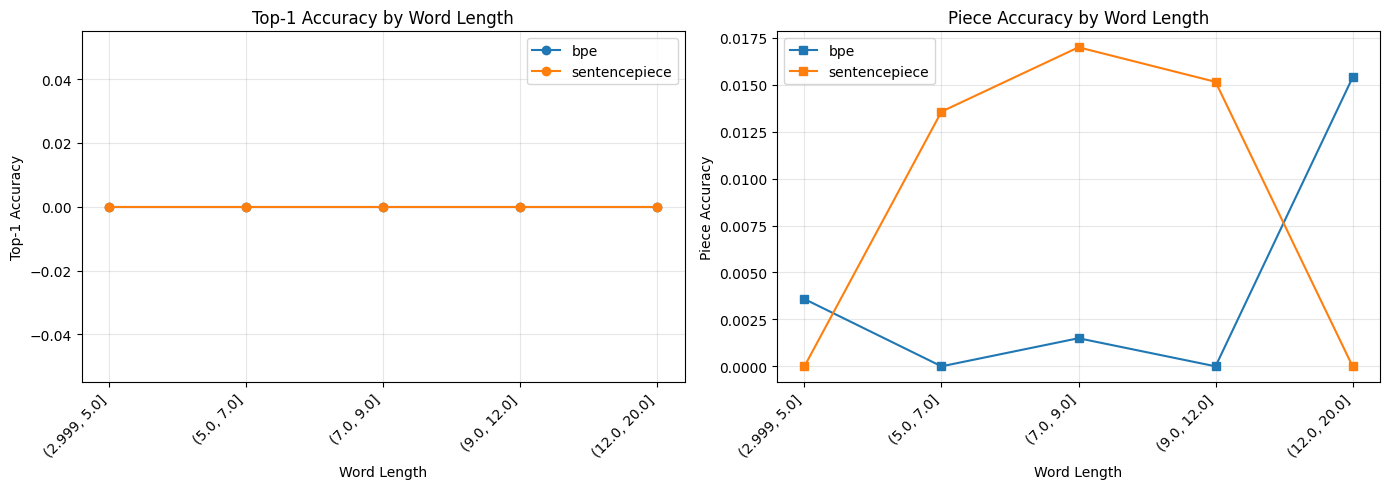


--- By Number of Subword Pieces ---


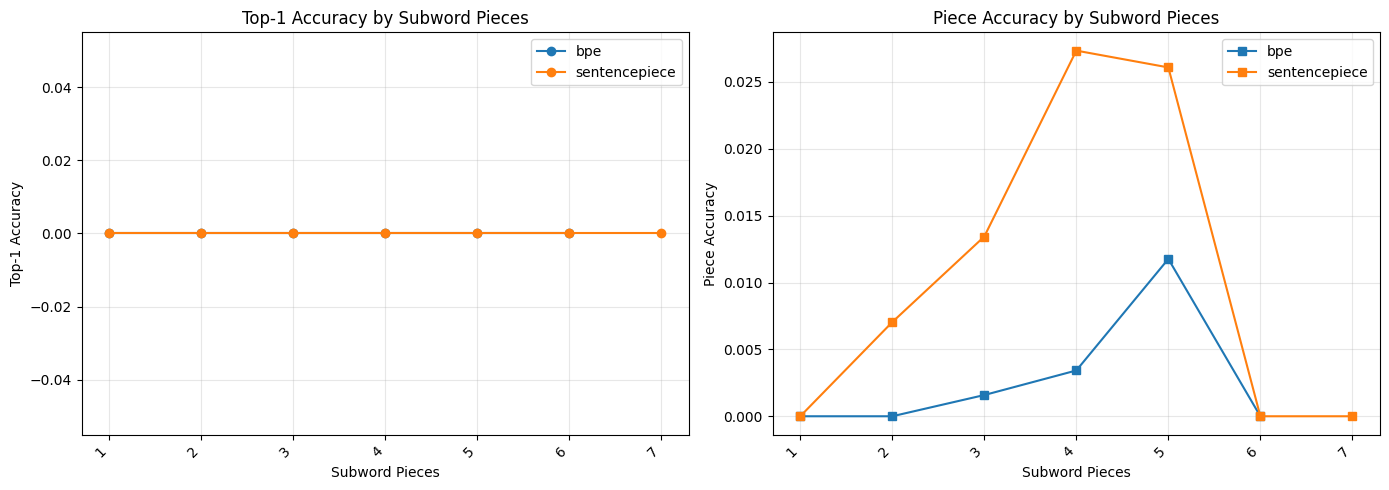


--- By Word Frequency ---


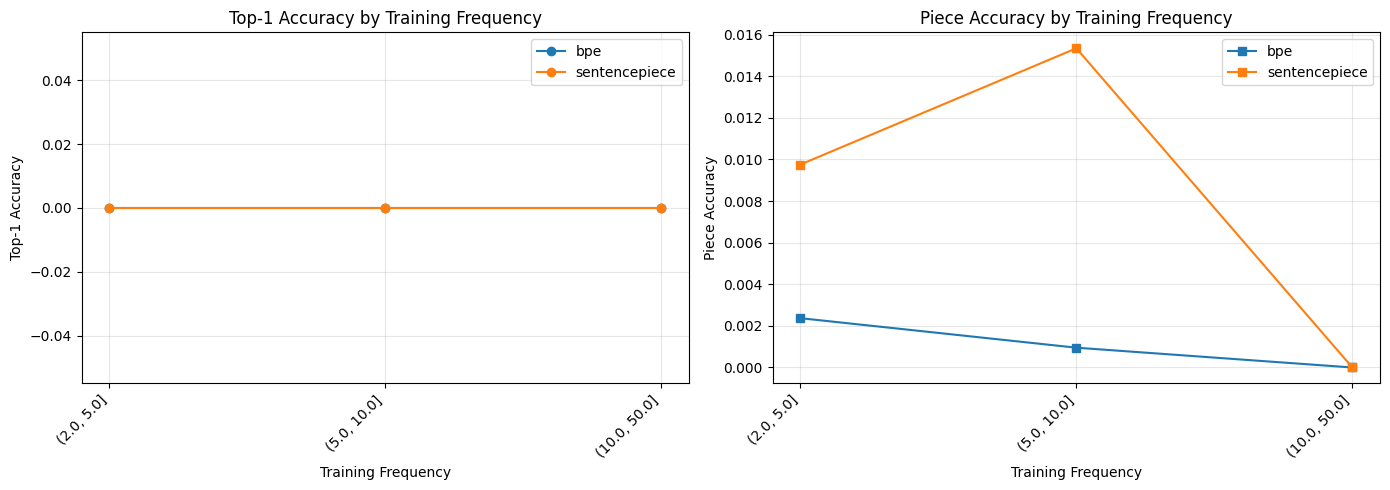


--- Summary by Tokenizer and Word Length ---


count  top1_acc  piece_acc
tokenizer     length_bucket                            
bpe           (2.999, 5.0]      93       0.0     0.0036
              (5.0, 7.0]       143       0.0     0.0000
              (7.0, 9.0]       167       0.0     0.0015
              (9.0, 12.0]       84       0.0     0.0000
              (12.0, 20.0]      13       0.0     0.0154
sentencepiece (2.999, 5.0]      79       0.0     0.0000
              (5.0, 7.0]       129       0.0     0.0136
              (7.0, 9.0]       153       0.0     0.0170
              (9.0, 12.0]       77       0.0     0.0152
              (12.0, 20.0]      12       0.0     0.0000


--- Summary by Tokenizer and Subword Piece Count ---


count  top1_acc
tokenizer     n_pieces                 
bpe           1             1       0.0
              2           195       0.0
              3           210       0.0
              4            73       0.0
              5            17       0.0
              6             4       0.0
sentencepiece 1            19       0.0
              2           213       0.0
              3           124       0.0
              4            64       0.0
              5            23       0.0
              6             6       0.0
              7             1       0.0


ANALYSIS: Wiki Medium-Frequency Words (Unified Evaluation)

--- By Word Length ---


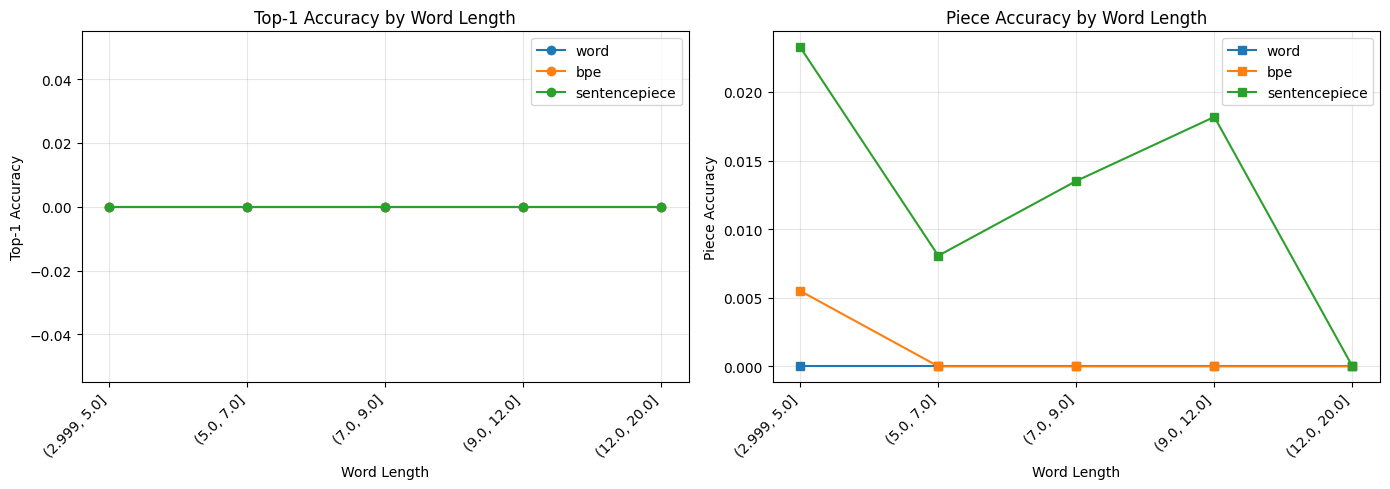


--- By Number of Subword Pieces ---


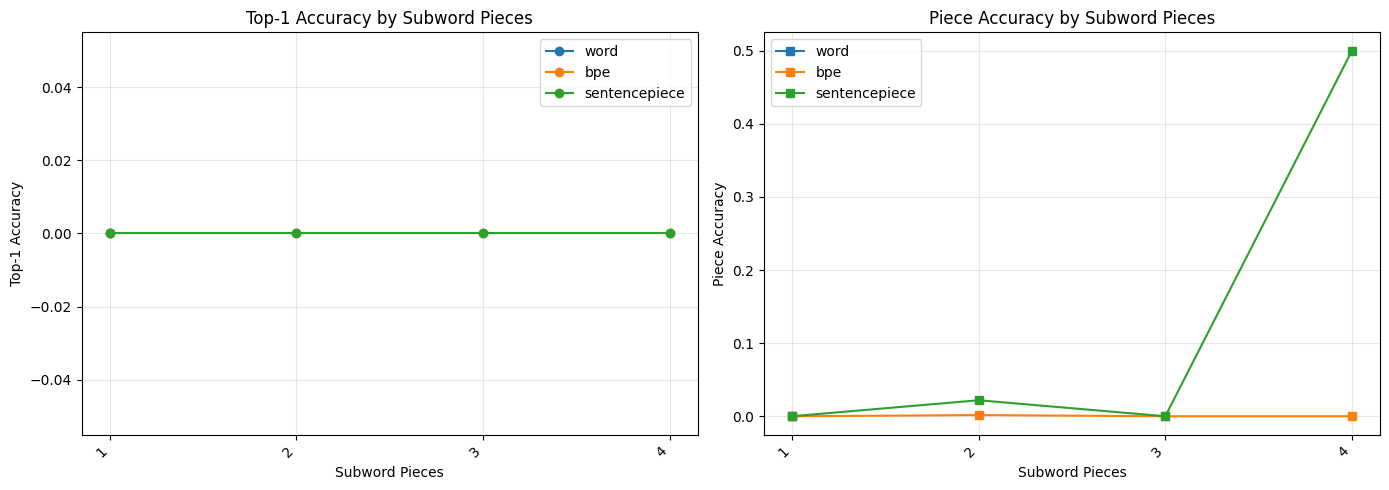


ANALYSIS: Shakespeare Rare Words (Unified Evaluation)

--- By Word Length ---


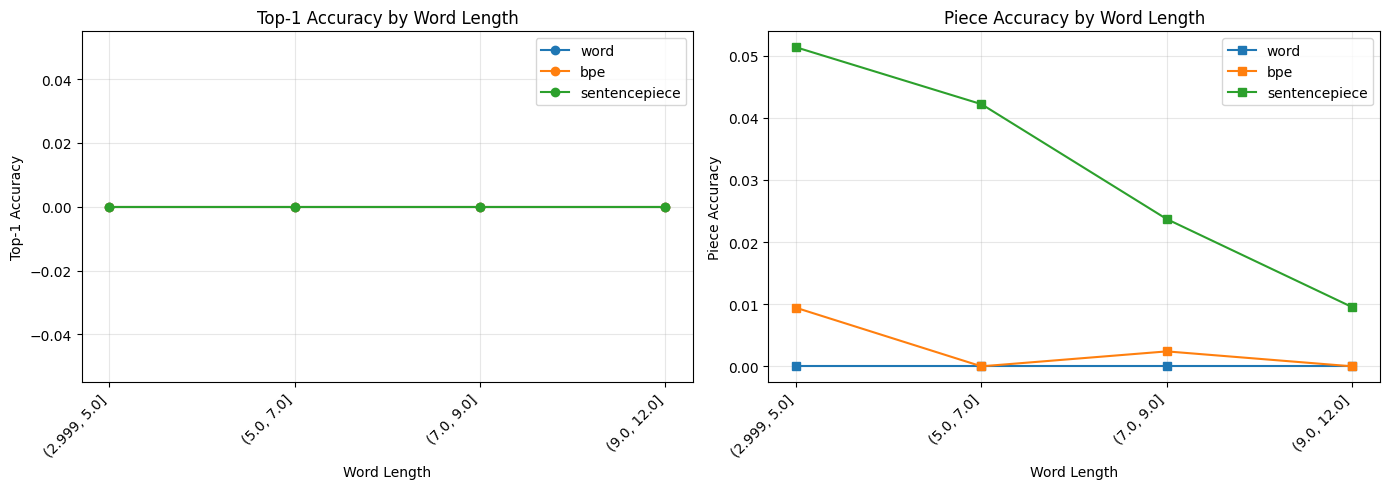


--- By Number of Subword Pieces ---


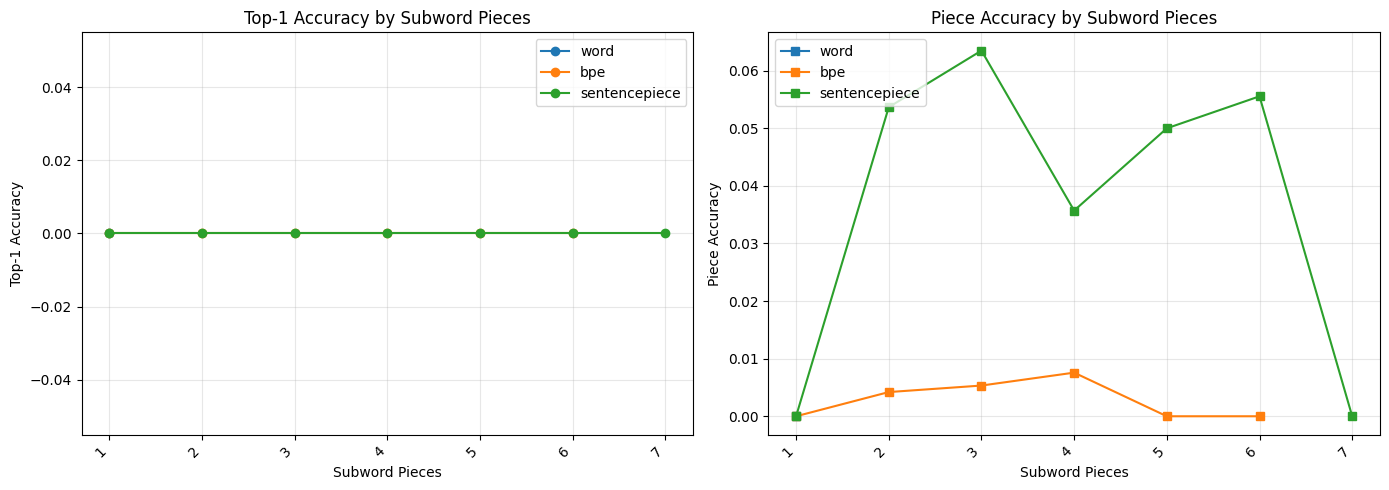


CROSS-DOMAIN COMPARISON: WikiText vs Shakespeare Rare Words


,wiki_usable,wiki_top1,wiki_top10,wiki_top50,wiki_top100,shake_usable,shake_top1,shake_top10,shake_top50,shake_top100
tokenizer,,,,,,,,,,
bpe,500,0.0,0.0,0.0,0.0,494,0.0,0.0,0.0000,0.0000
sentencepiece,450,0.0,0.0,0.0,0.0,418,0.0,0.0,0.0048,0.0048


In [22]:
# DETAILED ANALYSIS BREAKDOWNS
# Break down results by word length, frequency, and subword token count
import matplotlib.pyplot as plt
import numpy as np

def analyze_by_dimension(details_df, dimension_col, dimension_name, bins=None):
    """Analyze top-1 accuracy and piece accuracy by a given dimension."""
    if len(details_df) == 0:
        print(f"No data for {dimension_name} analysis.")
        return

    df = details_df.copy()

    if bins is not None:
        df["bucket"] = pd.cut(df[dimension_col], bins=bins, include_lowest=True)
    else:
        df["bucket"] = df[dimension_col]

    tokenizers = df["tokenizer"].unique()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Top-1 accuracy by dimension
    ax = axes[0]
    for tok in tokenizers:
        subset = df[df["tokenizer"] == tok]
        grouped = subset.groupby("bucket", observed=True)["top1"].mean()
        ax.plot(range(len(grouped)), grouped.values, marker="o", label=tok)
        ax.set_xticks(range(len(grouped)))
        ax.set_xticklabels([str(b) for b in grouped.index], rotation=45, ha="right")
    ax.set_xlabel(dimension_name)
    ax.set_ylabel("Top-1 Accuracy")
    ax.set_title(f"Top-1 Accuracy by {dimension_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Piece accuracy by dimension (if available)
    ax = axes[1]
    if "piece_accuracy" in df.columns:
        for tok in tokenizers:
            subset = df[df["tokenizer"] == tok]
            grouped = subset.groupby("bucket", observed=True)["piece_accuracy"].mean()
            ax.plot(range(len(grouped)), grouped.values, marker="s", label=tok)
            ax.set_xticks(range(len(grouped)))
            ax.set_xticklabels([str(b) for b in grouped.index], rotation=45, ha="right")
        ax.set_xlabel(dimension_name)
        ax.set_ylabel("Piece Accuracy")
        ax.set_title(f"Piece Accuracy by {dimension_name}")
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, "No piece_accuracy data", ha="center", va="center")

    plt.tight_layout()
    plt.savefig(str(RESULTS_DIR / f"analysis_by_{dimension_col}.png"), dpi=150, bbox_inches="tight")
    plt.show()

# Add word length and frequency to unified details
def enrich_details(details_df, freq_counter):
    """Add word_length and word_freq columns to detail dataframes."""
    df = details_df.copy()
    df["word_length"] = df["target_word"].str.len()
    df["word_freq"] = df["target_word"].apply(lambda w: freq_counter.get(w.lower(), freq_counter.get(w, 0)))
    return df

# Rebuild freq counter
train_tokens_analysis = word_tokenize_text(wikitext_train_text)
freq_counter_analysis = Counter(train_tokens_analysis)

print("=" * 60)
print("ANALYSIS: Wiki Rare Words (Unified Evaluation)")
print("=" * 60)

if len(wiki_rare_unified_details) > 0:
    enriched_rare = enrich_details(wiki_rare_unified_details, freq_counter_analysis)

    # By word length
    length_bins = [3, 5, 7, 9, 12, 20]
    print("\n--- By Word Length ---")
    analyze_by_dimension(enriched_rare, "word_length", "Word Length", bins=length_bins)

    # By number of subword pieces
    if "n_pieces" in enriched_rare.columns:
        print("\n--- By Number of Subword Pieces ---")
        analyze_by_dimension(enriched_rare, "n_pieces", "Subword Pieces")

    # By word frequency
    freq_bins = [0, 2, 5, 10, 50]
    print("\n--- By Word Frequency ---")
    analyze_by_dimension(enriched_rare, "word_freq", "Training Frequency", bins=freq_bins)

    # Summary table: per-tokenizer breakdown
    print("\n--- Summary by Tokenizer and Word Length ---")
    enriched_rare["length_bucket"] = pd.cut(enriched_rare["word_length"], bins=length_bins, include_lowest=True)
    summary_table = enriched_rare.groupby(["tokenizer", "length_bucket"], observed=True).agg(
        count=("top1", "size"),
        top1_acc=("top1", "mean"),
        piece_acc=("piece_accuracy", "mean") if "piece_accuracy" in enriched_rare.columns else ("top1", "mean"),
    ).round(4)
    display(summary_table)

    if "n_pieces" in enriched_rare.columns:
        print("\n--- Summary by Tokenizer and Subword Piece Count ---")
        summary_pieces = enriched_rare.groupby(["tokenizer", "n_pieces"], observed=True).agg(
            count=("top1", "size"),
            top1_acc=("top1", "mean"),
        ).round(4)
        display(summary_pieces)
else:
    print("No wiki rare unified details available.")

print("\n" + "=" * 60)
print("ANALYSIS: Wiki Medium-Frequency Words (Unified Evaluation)")
print("=" * 60)

if len(wiki_medium_unified_details) > 0:
    enriched_medium = enrich_details(wiki_medium_unified_details, freq_counter_analysis)

    length_bins = [3, 5, 7, 9, 12, 20]
    print("\n--- By Word Length ---")
    analyze_by_dimension(enriched_medium, "word_length", "Word Length", bins=length_bins)

    if "n_pieces" in enriched_medium.columns:
        print("\n--- By Number of Subword Pieces ---")
        analyze_by_dimension(enriched_medium, "n_pieces", "Subword Pieces")
else:
    print("No wiki medium unified details available.")

print("\n" + "=" * 60)
print("ANALYSIS: Shakespeare Rare Words (Unified Evaluation)")
print("=" * 60)

if len(shake_rare_unified_details) > 0:
    enriched_shake = enrich_details(shake_rare_unified_details, freq_counter_analysis)

    length_bins = [3, 5, 7, 9, 12, 20]
    print("\n--- By Word Length ---")
    analyze_by_dimension(enriched_shake, "word_length", "Word Length", bins=length_bins)

    if "n_pieces" in enriched_shake.columns:
        print("\n--- By Number of Subword Pieces ---")
        analyze_by_dimension(enriched_shake, "n_pieces", "Subword Pieces")
else:
    print("No Shakespeare rare unified details available.")

# Cross-domain comparison: WikiText vs Shakespeare rare words
print("\n" + "=" * 60)
print("CROSS-DOMAIN COMPARISON: WikiText vs Shakespeare Rare Words")
print("=" * 60)

if len(wiki_rare_unified_details) > 0 and len(shake_rare_unified_details) > 0:
    wiki_summary = wiki_rare_unified_details.groupby("tokenizer").agg(
        wiki_usable=("top1", "size"),
        wiki_top1=("top1", "mean"),
        wiki_top10=("top10", "mean"),
        wiki_top50=("top50", "mean"),
        wiki_top100=("top100", "mean"),
    ).round(4)

    shake_summary = shake_rare_unified_details.groupby("tokenizer").agg(
        shake_usable=("top1", "size"),
        shake_top1=("top1", "mean"),
        shake_top10=("top10", "mean"),
        shake_top50=("top50", "mean"),
        shake_top100=("top100", "mean"),
    ).round(4)

    cross_domain = wiki_summary.join(shake_summary)
    display(cross_domain)
else:
    print("Insufficient data for cross-domain comparison.")
